#  Mini Project - EDA (Exploratory Data Analysis) on Loans Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
 data = pd.read_csv("E:/Anmol/MIcrosoft AI Jupyter/Data Files/LoansData (1).csv")

### **Data understanding**

In [3]:
print(data.shape)

print(data.info())               # To check the metadata (information about the data) 

(2500, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LoanID                          2500 non-null   int64  
 1   Amount.Requested                2499 non-null   float64
 2   Amount.Funded.By.Investors      2499 non-null   float64
 3   Interest.Rate                   2498 non-null   object 
 4   Loan.Length                     2500 non-null   object 
 5   Loan.Purpose                    2500 non-null   object 
 6   Debt.To.Income.Ratio            2499 non-null   object 
 7   State                           2500 non-null   object 
 8   Home.Ownership                  2499 non-null   object 
 9   Monthly.Income                  2499 non-null   float64
 10  FICO.Range                      2498 non-null   object 
 11  Open.CREDIT.Lines               2497 non-null   float64
 12  Revolving.CREDIT.Balanc

### Data preprocessing started

### **Naming Convention on Headers**

In [71]:
# Replace . with _ in headings 

# Method 1 :- data.columns = data.columns.str.replace('.', '_')

# Method 2 :- Using list comprehension to replace '.' with '_' in headings

data.columns = [i. replace('.', '_') for i in data.columns]
print(data.info())  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LoanID                          2500 non-null   int64  
 1   Amount_Requested                2499 non-null   float64
 2   Amount_Funded_By_Investors      2499 non-null   float64
 3   Interest_Rate                   2498 non-null   object 
 4   Loan_Length                     2500 non-null   object 
 5   Loan_Purpose                    2500 non-null   object 
 6   Debt_To_Income_Ratio            2499 non-null   object 
 7   State                           2500 non-null   object 
 8   Home_Ownership                  2499 non-null   object 
 9   Monthly_Income                  2499 non-null   float64
 10  FICO_Range                      2498 non-null   object 
 11  Open_CREDIT_Lines               2497 non-null   float64
 12  Revolving_CREDIT_Balance        24

### **Type Casting**

In [72]:
data['Interest_Rate'] = data['Interest_Rate'].str.replace('%', '').astype(float)

data["Loan_Length"] = data["Loan_Length"].str.replace(' months', '').astype(float)

data['Debt_To_Income_Ratio'] = data['Debt_To_Income_Ratio'].str.replace("%","").astype("float")

data['Employment_Length'] = data['Employment_Length'].str.replace('years','').str.replace('year','').str.replace('<','').str.replace('+','').astype('float')

data['FICO_Range'] = data['FICO_Range'].str.split('-', expand = True)[0].astype(float)


In [73]:
# Creating a copy of the data
copy_data = data.copy()

print("Shape of the copy_data is:-", copy_data.shape)

Shape of the copy_data is:- (2500, 15)


### **Separating categorical and numerical data**

In [74]:
categorical = [var for var in copy_data.columns if copy_data[var].dtype == 'O']
cat_data = copy_data[categorical]
print(cat_data.head(5))
print("\n")

numerical = [var for var in copy_data.columns if copy_data[var].dtype != 'O']
num_data = copy_data[numerical]
print(num_data.head(5))


         Loan_Purpose State Home_Ownership
0  debt_consolidation    SC       MORTGAGE
1  debt_consolidation    TX       MORTGAGE
2  debt_consolidation    CA       MORTGAGE
3  debt_consolidation    KS       MORTGAGE
4         credit_card    NJ           RENT


   LoanID  Amount_Requested  Amount_Funded_By_Investors  Interest_Rate  \
0       1           20000.0                     20000.0           8.90   
1       2           19200.0                     19200.0          12.12   
2       3           35000.0                     35000.0          21.98   
3       4           10000.0                      9975.0           9.99   
4       5           12000.0                     12000.0          11.71   

   Loan_Length  Debt_To_Income_Ratio  Monthly_Income  FICO_Range  \
0         36.0                 14.90         6541.67       735.0   
1         36.0                 28.36         4583.33       715.0   
2         60.0                 23.81        11500.00       690.0   
3         36.0         

### **Dealing with duplicate data**

In [75]:
dup_data = copy_data.duplicated().sum()                      # To check the number of duplicate rows
print("Number of duplicate rows are :- ", dup_data)


# Deleting duplicate data if any
if dup_data > 0:
    data.drop_duplicates(inplace=True)
    print("Duplicate rows deleted") 


Number of duplicate rows are :-  0


### **Missing Value Treatment on numerical and categorical data**

In [76]:
# Checking missing value
mis_value = num_data.isna().sum()                   # Method 1 to check missing values
print("Missing values are :- \n", mis_value)

    # num_data.isnull().sum()                       # Method 2 to check missing values

Missing values are :- 
 LoanID                             0
Amount_Requested                   1
Amount_Funded_By_Investors         1
Interest_Rate                      2
Loan_Length                        0
Debt_To_Income_Ratio               1
Monthly_Income                     1
FICO_Range                         2
Open_CREDIT_Lines                  3
Revolving_CREDIT_Balance           3
Inquiries_in_the_Last_6_Months     3
Employment_Length                 77
dtype: int64


In [77]:
# we can use the following method to fill missing values when the data is not separated into numerical and categorical data

def miss_value_treat(s):
    if s.dtype == 'O':
        s = s.fillna(s.mode())
    else:
        s = s.fillna(s.median())
    return s

In [78]:
data = data.apply(miss_value_treat)                   # This apply method is used  implement any function on the data

In [79]:
# Method 1
# we can use the following method to fill missing values in numerical data

for i in num_data.columns:       
        num_data[i] = num_data[i].fillna(num_data[i].median())
print("Missing values after treatment are :- \n", num_data.isna().sum())

# we can use the following method to fill missing values in categorical data
'''
for i in cat_data.columns:
        cat_data[i] = cat_data[i].fillna(cat_data[i].mode()[0])
print("Missing values after treatment are :- \n", cat_data.isna().sum())
'''

Missing values after treatment are :- 
 LoanID                            0
Amount_Requested                  0
Amount_Funded_By_Investors        0
Interest_Rate                     0
Loan_Length                       0
Debt_To_Income_Ratio              0
Monthly_Income                    0
FICO_Range                        0
Open_CREDIT_Lines                 0
Revolving_CREDIT_Balance          0
Inquiries_in_the_Last_6_Months    0
Employment_Length                 0
dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3820650959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_data[i] = num_data[i].fillna(num_data[i].median())
C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3820650959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_data[i] = num_data[i].fillna(num_data[i].median())
C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3820650959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

'\nfor i in cat_data.columns:\n        cat_data[i] = cat_data[i].fillna(cat_data[i].mode()[0])\nprint("Missing values after treatment are :- \n", cat_data.isna().sum())\n'

In [80]:
# Method 2
# By deleting the row with missing value in both numerical and categorical data

# Deleting the row with index 2492 from both numerical and categorical data
# This is done to remove the row with missing values in both numerical and categorical data

num_data.drop(2492, inplace=True)
num_data.reset_index(inplace=True)              # Resseting the index after dropping the row in numerical data
num_data.drop(columns=['index'], inplace=True)
print("Missing values are :- \n", cat_data.isna().sum() )

cat_data.drop(2492, inplace=True)
cat_data.reset_index(inplace=True)              # Resseting the index after dropping the row in categorical data  
cat_data.drop(columns=['index'], inplace=True)                  
print("Missing values are :- \n", cat_data.isna().sum() )
print(num_data)
print(cat_data)


Missing values are :- 
 Loan_Purpose      0
State             0
Home_Ownership    1
dtype: int64
Missing values are :- 
 Loan_Purpose      0
State             0
Home_Ownership    0
dtype: int64
      LoanID  Amount_Requested  Amount_Funded_By_Investors  Interest_Rate  \
0          1           20000.0                    20000.00           8.90   
1          2           19200.0                    19200.00          12.12   
2          3           35000.0                    35000.00          21.98   
3          4           10000.0                     9975.00           9.99   
4          5           12000.0                    12000.00          11.71   
...      ...               ...                         ...            ...   
2494    2496           30000.0                    29950.00          16.77   
2495    2497           16000.0                    16000.00          14.09   
2496    2498           10000.0                    10000.00          13.99   
2497    2499            6000.0      

C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3910138892.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_data.drop(2492, inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3910138892.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_data.drop(columns=['index'], inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\3910138892.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_data.drop(2492, i

In [81]:
# Always use nunique() and value_counts() methods on catagorical variables.
cat_data.columns
cat_data.Loan_Purpose.nunique
cat_data.Loan_Purpose.value_counts() #No. of times occurence of a value

Loan_Purpose
debt_consolidation    1306
credit_card            444
other                  201
home_improvement       152
major_purchase         101
small_business          87
car                     50
wedding                 39
medical                 30
moving                  29
vacation                21
house                   20
educational             15
renewable_energy         4
Name: count, dtype: int64

### **Outlier Treatment Process on numerical data**

In [82]:
# Outlier Treatment
# Outliers are always clipped at their cutoffs
# Lower Outliers clipped at lower cutoff and upper outliers at upper cutoffs.

In [83]:
# If there is a large no. of outliers present then 
# outlier treatment is not applied for that column as it might cause very similiar kind of data in every row

In [84]:
# Variables at which Outlier treatment should be applied ?

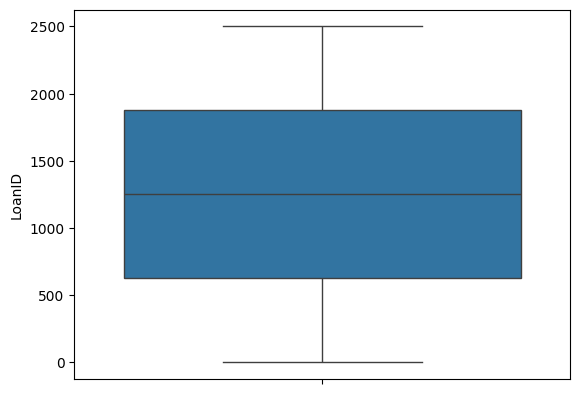

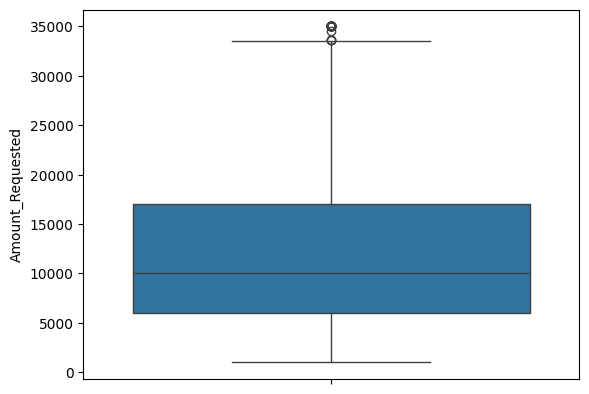

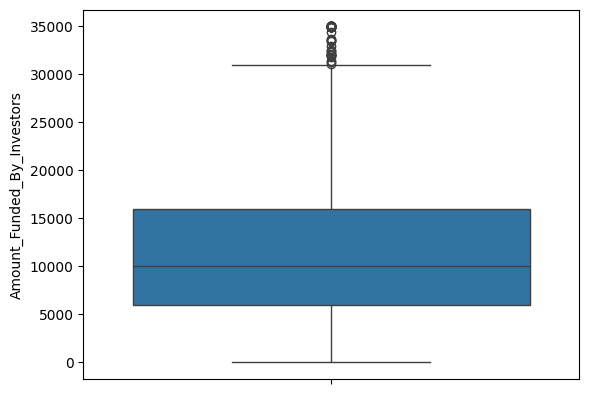

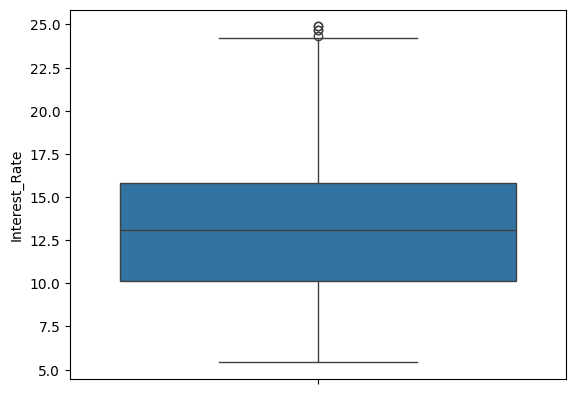

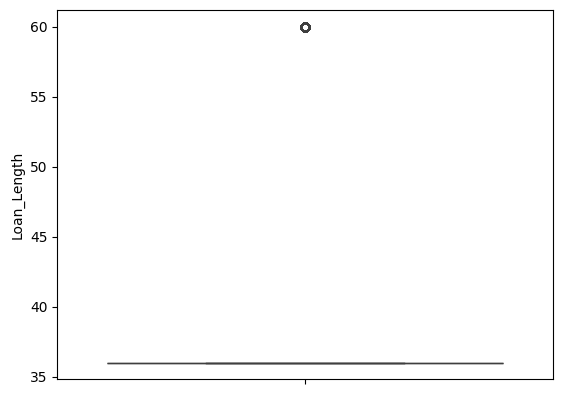

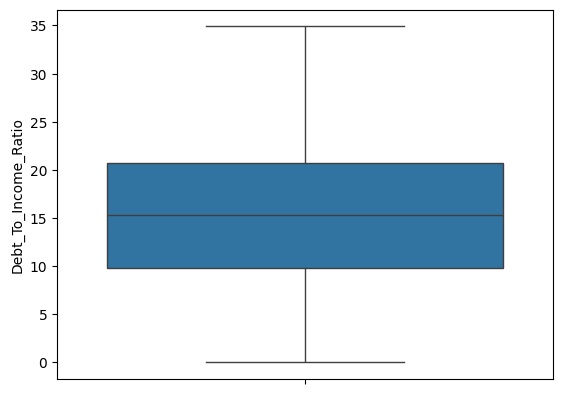

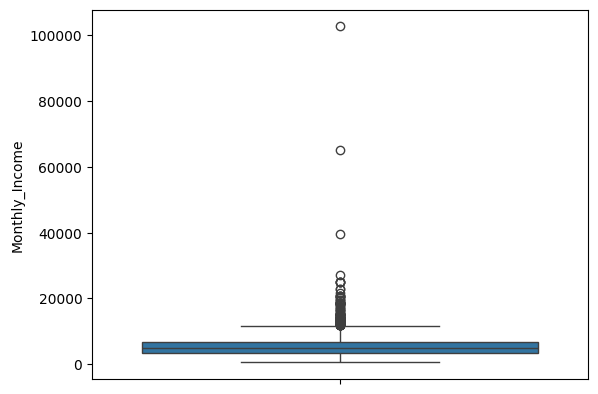

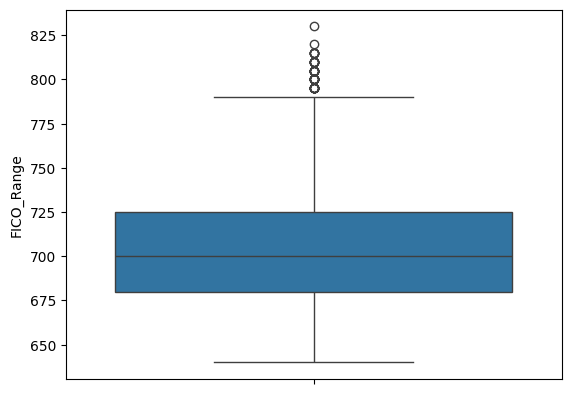

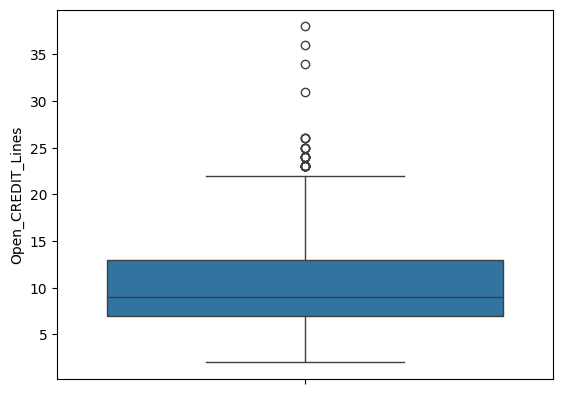

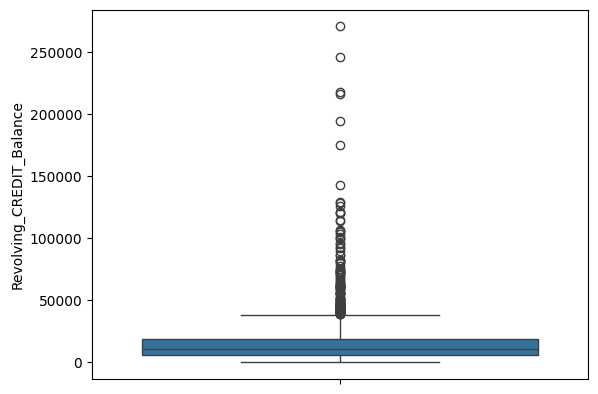

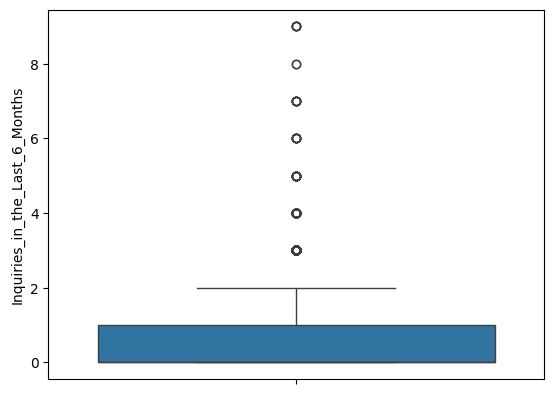

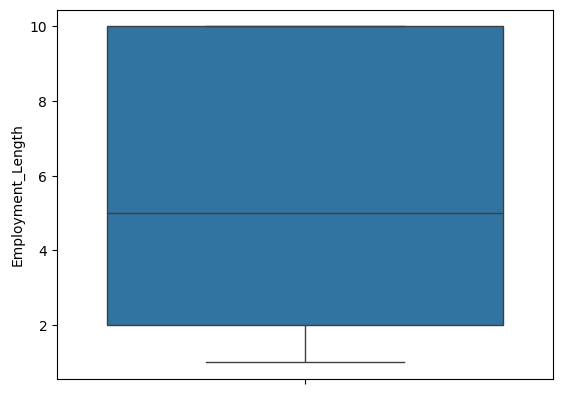

In [85]:
# Visualizing the outliers in numerical data using boxplot 
for col in num_data:

    sns.boxplot(num_data[col])

    plt.show()

In [86]:
def outliertreat_IQR(d):
    m = d.quantile(0.5)          # median in box plot
    q1 = d.quantile(0.25)        # Q1 in box plot
    q3 = d.quantile(0.75)        # Q3 in box plot
    q_1p = d.quantile(0.01)      # percentile method lower 1% cutoff
    q_99p = d.quantile(0.99)     # percentile method upper 1% cutoff
    iqr = q3 - q1  
    lc = q1 - 1.5*iqr
    uc = q3 + 1.5*iqr
    return lc,uc

In [87]:
num_data.apply(outliertreat_IQR)             # This will return the lower and upper bounds for each column in numerical data

,LoanID,Amount_Requested,Amount_Funded_By_Investors,Interest_Rate,Loan_Length,Debt_To_Income_Ratio,Monthly_Income,FICO_Range,Open_CREDIT_Lines,Revolving_CREDIT_Balance,Inquiries_in_the_Last_6_Months,Employment_Length
0,-1248.0,-10500.0,-9000.0,1.70,36.0,-6.6375,-1450.0,612.5,-2.0,-14305.5,-1.5,-10.0
1,3748.0,33500.0,31000.0,24.26,36.0,37.0625,11750.0,792.5,22.0,38742.5,2.5,22.0


In [88]:
# Making 2 copies of the numerical data to treat outliers

num_copy1 = num_data.copy() # First copy to perform outlier treatment on selective variables
num_copy2 = num_data.copy() # Second copy to perform outlier treatment on ALL variables.

In [89]:
num_copy1.columns

Index(['LoanID', 'Amount_Requested', 'Amount_Funded_By_Investors',
       'Interest_Rate', 'Loan_Length', 'Debt_To_Income_Ratio',
       'Monthly_Income', 'FICO_Range', 'Open_CREDIT_Lines',
       'Revolving_CREDIT_Balance', 'Inquiries_in_the_Last_6_Months',
       'Employment_Length'],
      dtype='object')

In [90]:
# In the first copy we are treating outliers by clipping the values to the lower and upper bounds
li = ['LoanID','Loan_Length','Monthly_Income','Revolving_CREDIT_Balance','Inquiries_in_the_last_6_Months']
for i in num_copy1:
    if i not in li:
        lc,uc = outliertreat_IQR(num_copy1[i])
        num_copy1[i] = num_copy1[i].clip(lc, uc)

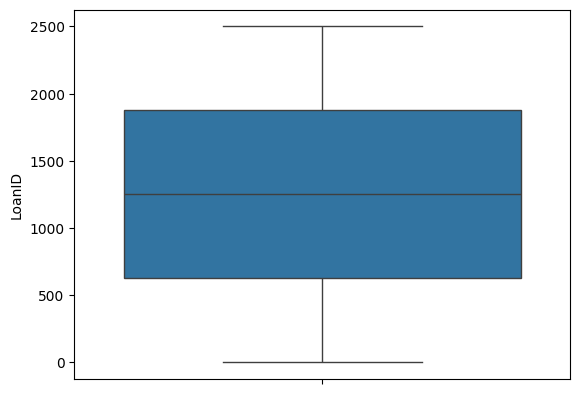

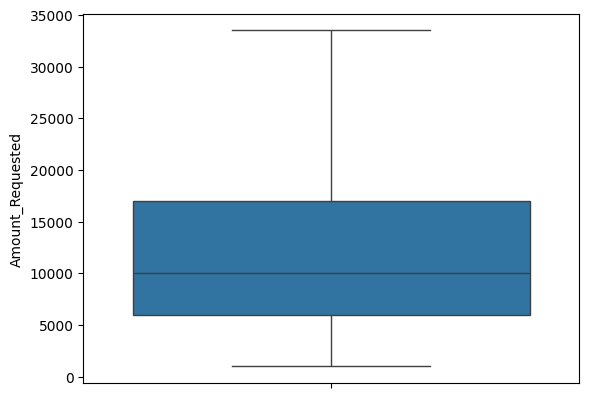

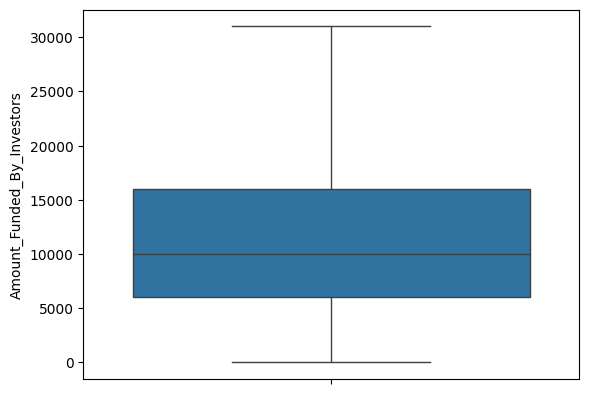

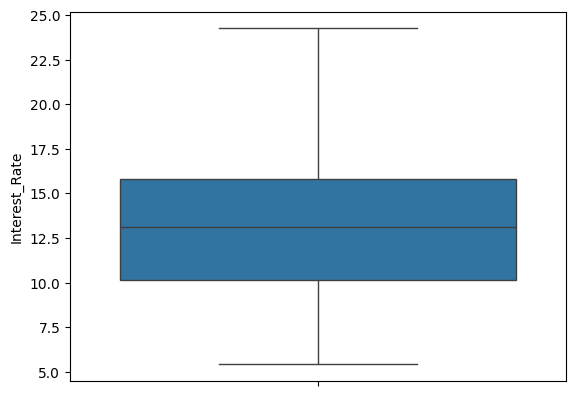

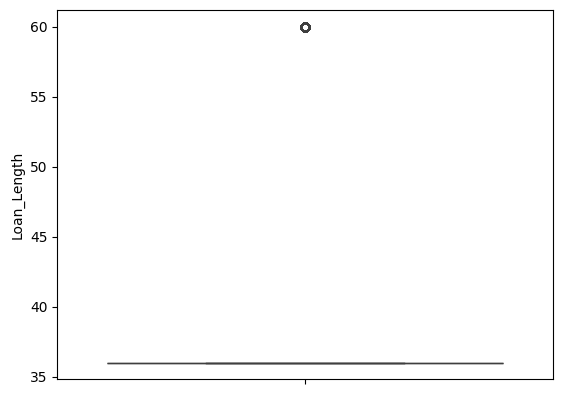

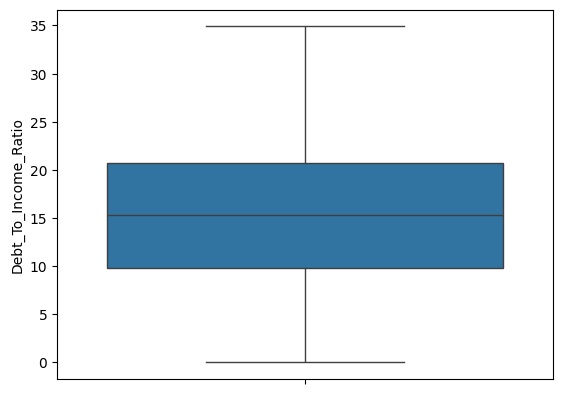

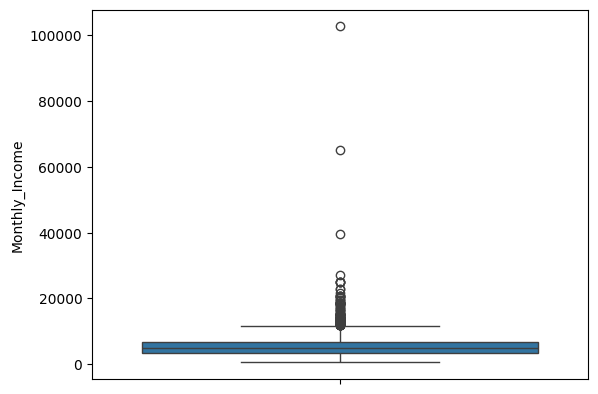

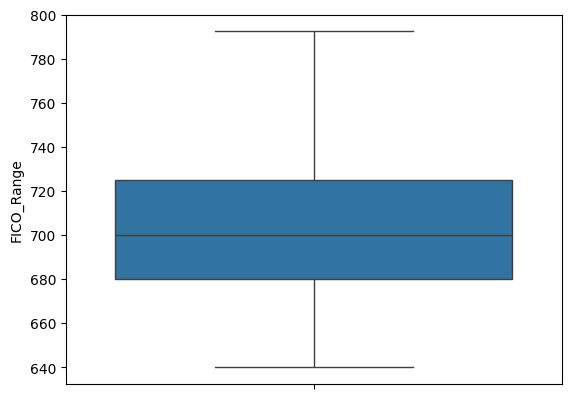

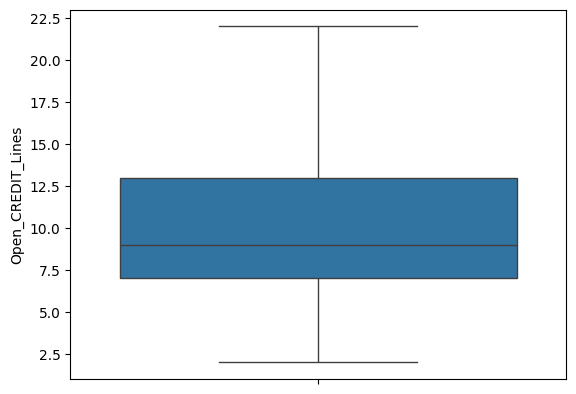

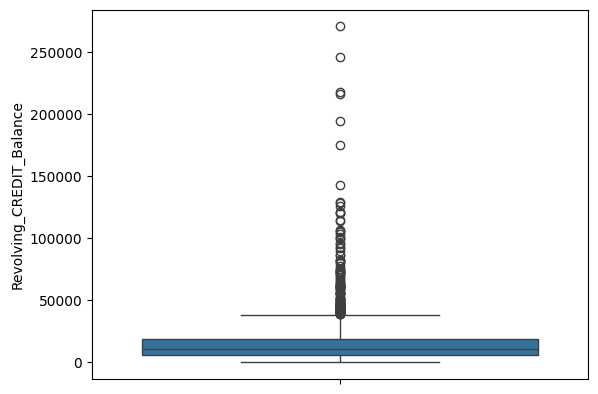

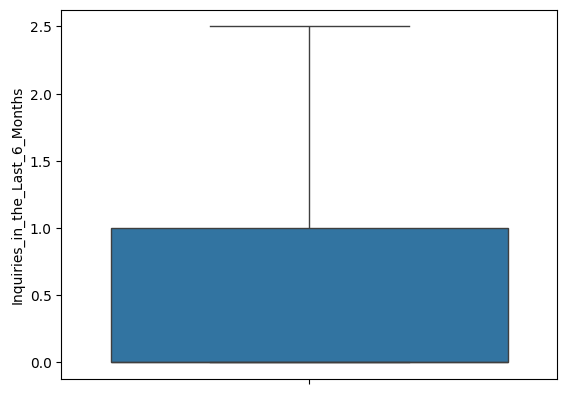

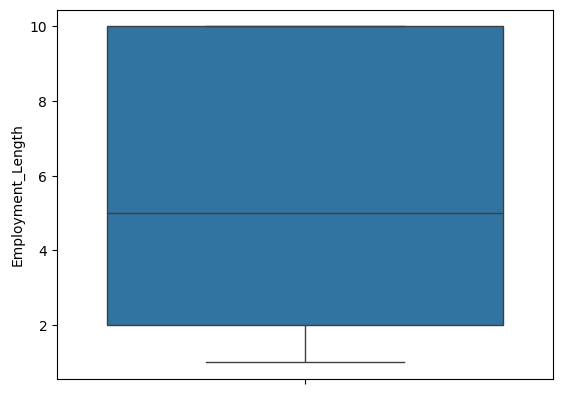

In [91]:
# Checking whether outliers have been treated or not.
for col in num_copy1:

    sns.boxplot(num_copy1[col])

    plt.show()

In [92]:
num_copy1.shape

(2499, 12)

In [93]:
cat_data.shape


(2499, 3)

In [94]:
# In the categorical data we are adding the LoanID column from the numerical data so that we can do merging later

cat_data['Loan_id'] = num_copy1['LoanID']
print(cat_data)

            Loan_Purpose State Home_Ownership  Loan_id
0     debt_consolidation    SC       MORTGAGE        1
1     debt_consolidation    TX       MORTGAGE        2
2     debt_consolidation    CA       MORTGAGE        3
3     debt_consolidation    KS       MORTGAGE        4
4            credit_card    NJ           RENT        5
...                  ...   ...            ...      ...
2494  debt_consolidation    NY       MORTGAGE     2496
2495    home_improvement    MD            OWN     2497
2496  debt_consolidation    PA       MORTGAGE     2498
2497      major_purchase    NJ           RENT     2499
2498  debt_consolidation    NY           RENT     2500

[2499 rows x 4 columns]


C:\Users\Dell\AppData\Local\Temp\ipykernel_15212\921493760.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_data['Loan_id'] = num_copy1['LoanID']


In [95]:
# Merging the numerical and categorical data

merged_data = pd.merge(num_copy1, cat_data, left_on='LoanID',right_on='Loan_id')
print("Shape of merged_data :-", merged_data.shape)


Shape of merged_data :- (2499, 16)


In [96]:
merged_data.head(10)

,LoanID,Amount_Requested,Amount_Funded_By_Investors,Interest_Rate,Loan_Length,Debt_To_Income_Ratio,Monthly_Income,FICO_Range,Open_CREDIT_Lines,Revolving_CREDIT_Balance,Inquiries_in_the_Last_6_Months,Employment_Length,Loan_Purpose,State,Home_Ownership,Loan_id
0,1,20000.0,20000.0,8.90,36.0,14.90,6541.67,735.0,14.0,14272.0,2.0,1.0,debt_consolidation,SC,MORTGAGE,1
1,2,19200.0,19200.0,12.12,36.0,28.36,4583.33,715.0,12.0,11140.0,1.0,2.0,debt_consolidation,TX,MORTGAGE,2
2,3,33500.0,31000.0,21.98,60.0,23.81,11500.00,690.0,14.0,21977.0,1.0,2.0,debt_consolidation,CA,MORTGAGE,3
3,4,10000.0,9975.0,9.99,36.0,14.30,3833.33,695.0,10.0,9346.0,0.0,5.0,debt_consolidation,KS,MORTGAGE,4
4,5,12000.0,12000.0,11.71,36.0,18.78,3195.00,695.0,11.0,14469.0,0.0,9.0,credit_card,NJ,RENT,5
5,6,6000.0,6000.0,15.31,36.0,20.05,4891.67,670.0,17.0,10391.0,2.0,3.0,other,CT,OWN,6
6,7,10000.0,10000.0,7.90,36.0,26.09,2916.67,720.0,10.0,15957.0,0.0,10.0,debt_consolidation,MA,RENT,7
7,8,33500.0,31000.0,17.14,60.0,14.70,13863.42,705.0,12.0,27874.0,0.0,10.0,credit_card,LA,MORTGAGE,8
8,9,14675.0,14675.0,14.33,36.0,26.92,3150.00,685.0,9.0,7246.0,1.0,8.0,credit_card,CA,RENT,9
9,10,7000.0,7000.0,6.91,36.0,7.10,5000.00,715.0,8.0,7612.0,0.0,3.0,credit_card,CA,RENT,10


### **Categorical Treatment**

**ML model only takes numerical type data, thus categorical data has to be converted into numerical using one hot encoding.**

Categorical Data : One-Hot Encoding : Conversion of categorical data into Numerical (Vectorized) form

In [97]:
cat_data.Home_Ownership.nunique()

5

In [98]:
cat_data.Loan_Purpose.nunique()

14

In [99]:
cat_data.State.nunique()    # Too many columns will be added if one hot encoding applied on state
                            # Thus, dropping it 

46

In [100]:
merged_copy = merged_data.copy()

In [101]:
# One-Hot Encoding on categorical variables - 'Home_Ownership' and 'Loan_Purpose' 

merged_copy = pd.get_dummies(merged_data,columns = ['Home_Ownership','Loan_Purpose'],dtype = int)  #One-Hot Encoding

merged_copy.shape

(2499, 33)

In [102]:
# Dropping the State and Loan_id columns as they are not needed for analysis

merged_copy = merged_copy.drop(columns=['State','Loan_id','LoanID'])
print("Shape of merged_copy data :-", merged_copy.shape)

Shape of merged_copy data :- (2499, 30)


In [103]:
merged_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Amount_Requested                 2499 non-null   float64
 1   Amount_Funded_By_Investors       2499 non-null   float64
 2   Interest_Rate                    2499 non-null   float64
 3   Loan_Length                      2499 non-null   float64
 4   Debt_To_Income_Ratio             2499 non-null   float64
 5   Monthly_Income                   2499 non-null   float64
 6   FICO_Range                       2499 non-null   float64
 7   Open_CREDIT_Lines                2499 non-null   float64
 8   Revolving_CREDIT_Balance         2499 non-null   float64
 9   Inquiries_in_the_Last_6_Months   2499 non-null   float64
 10  Employment_Length                2499 non-null   float64
 11  Home_Ownership_MORTGAGE          2499 non-null   int64  
 12  Home_Ownership_NONE 

### **Transformation on the data**

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


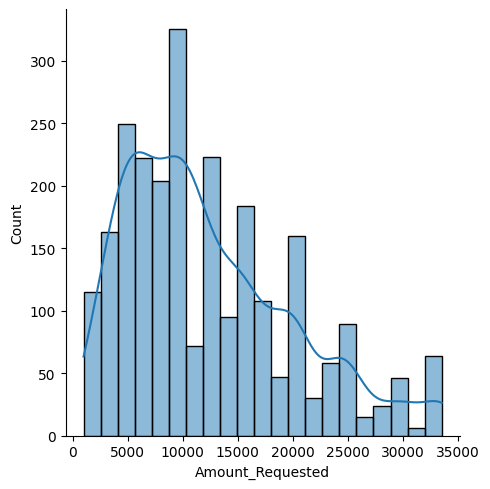

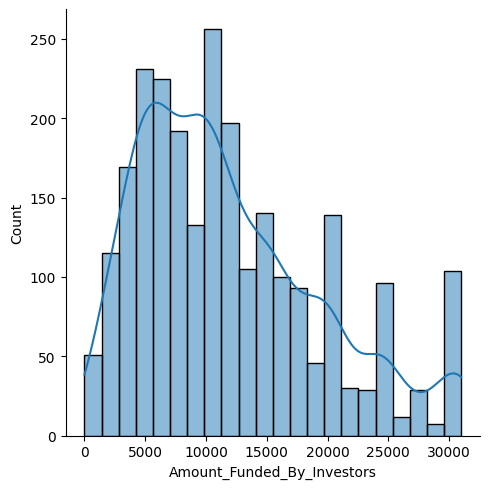

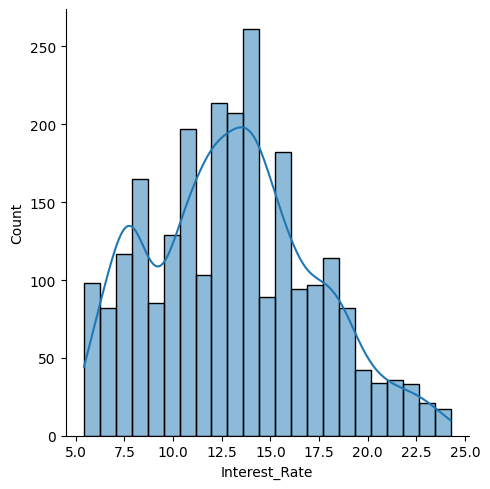

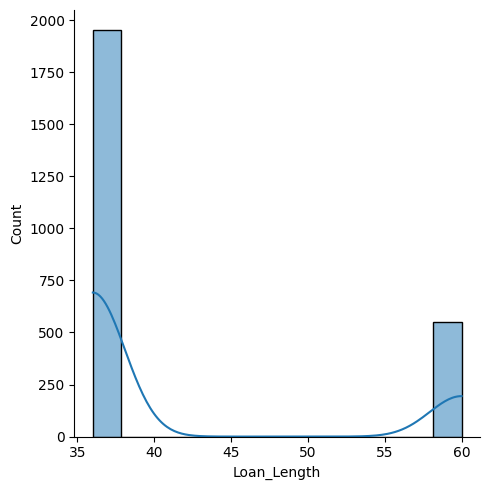

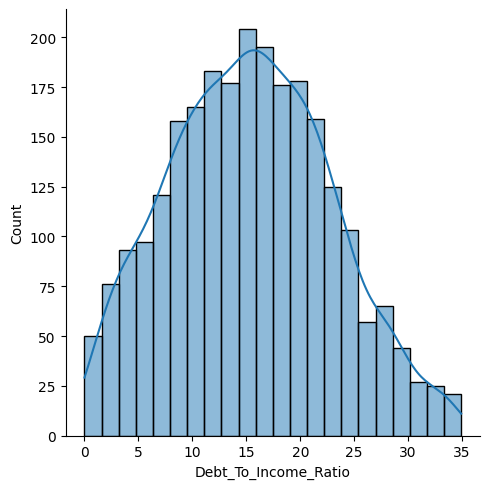

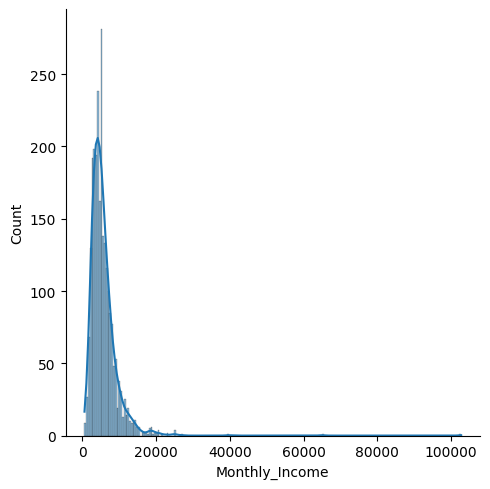

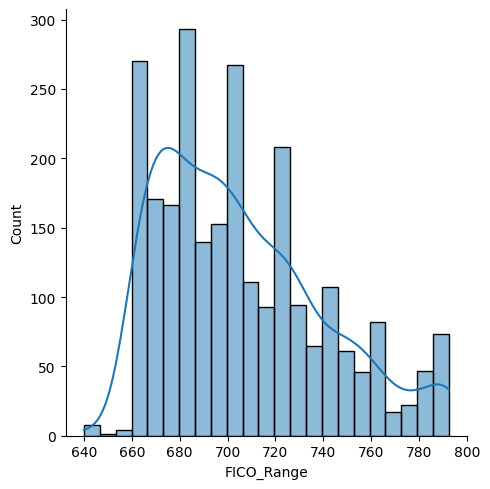

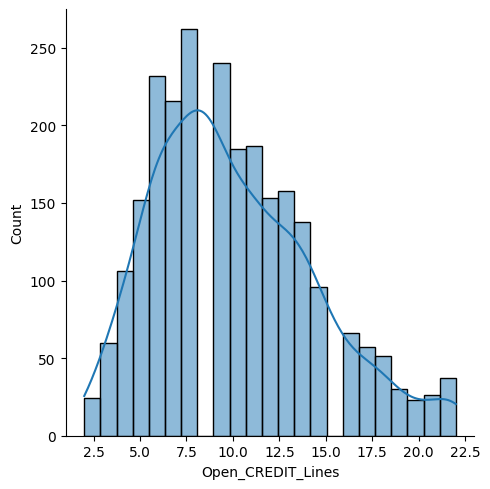

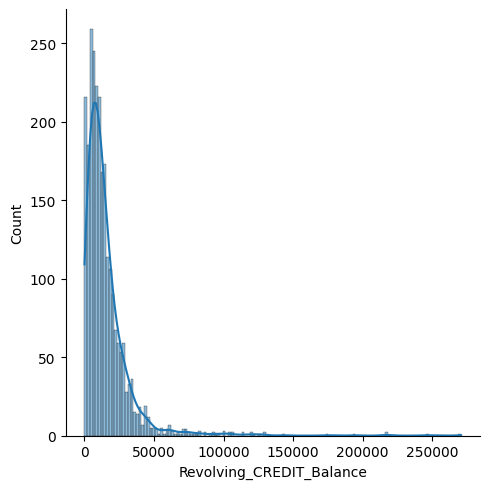

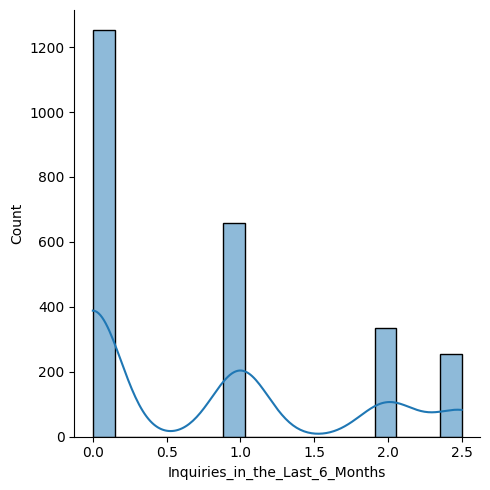

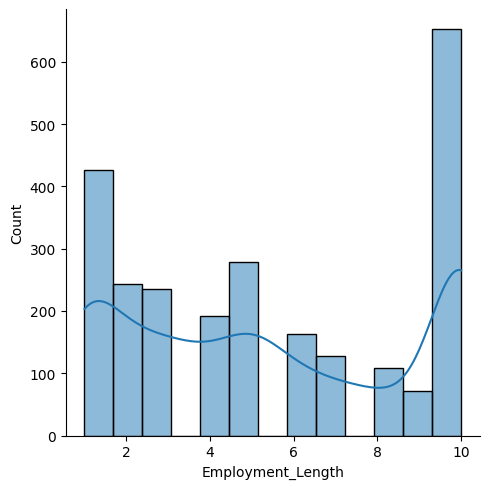

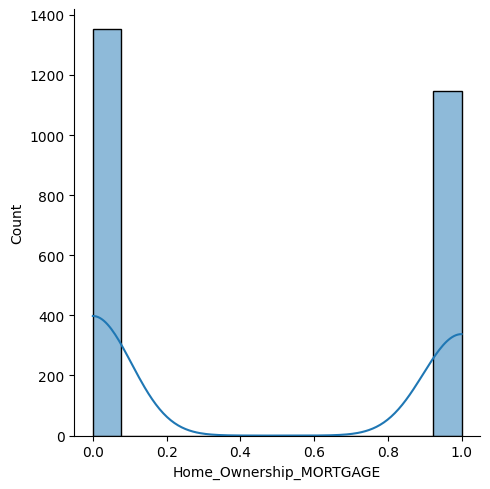

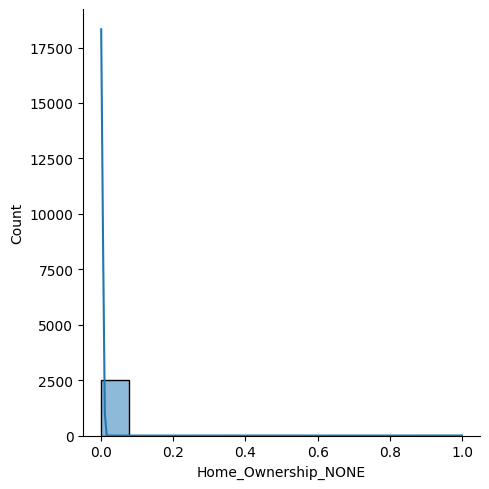

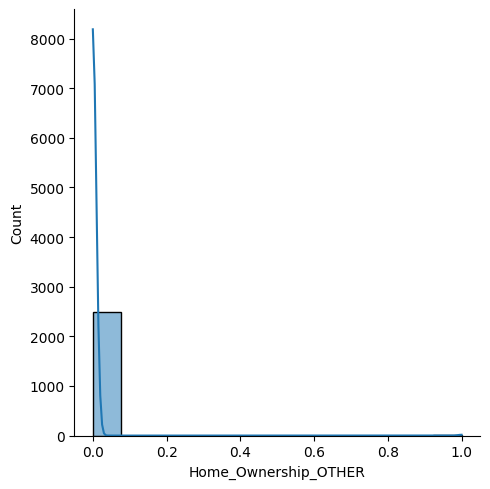

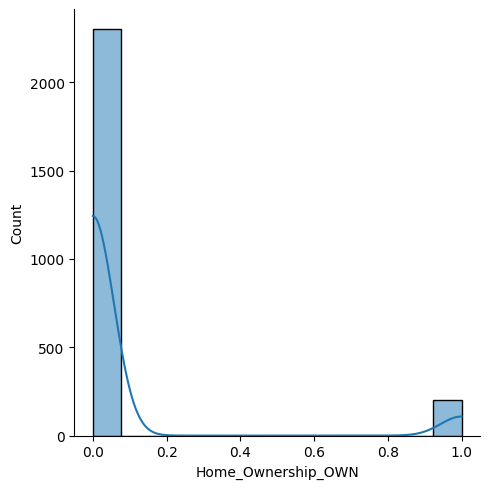

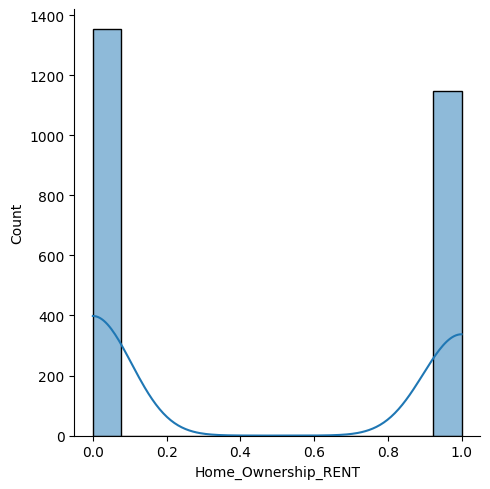

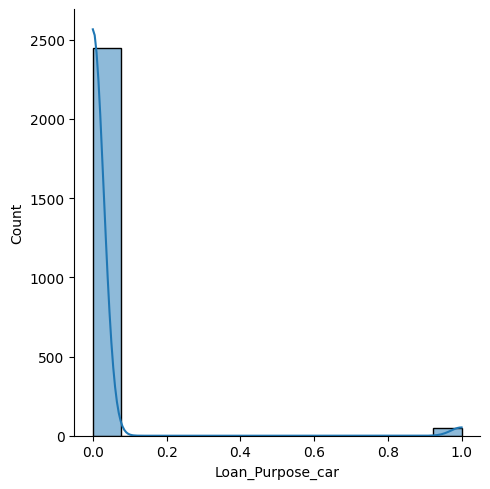

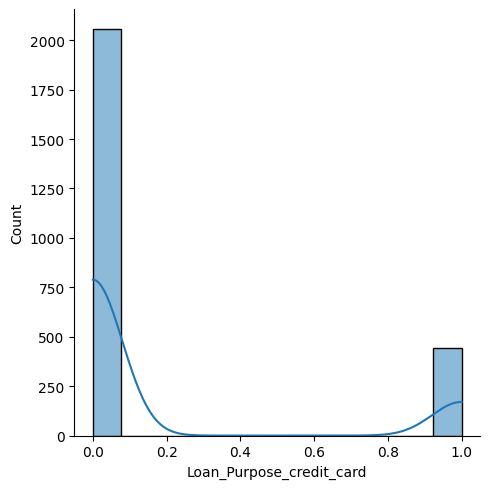

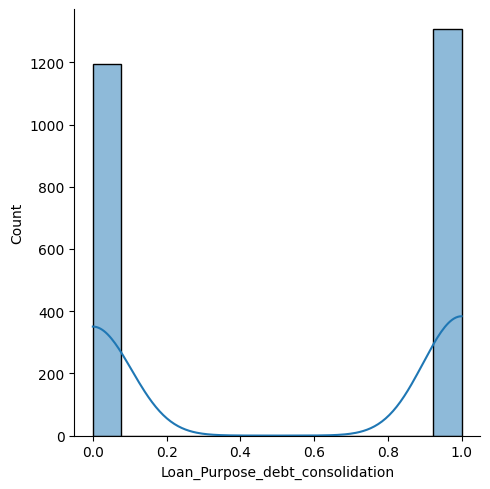

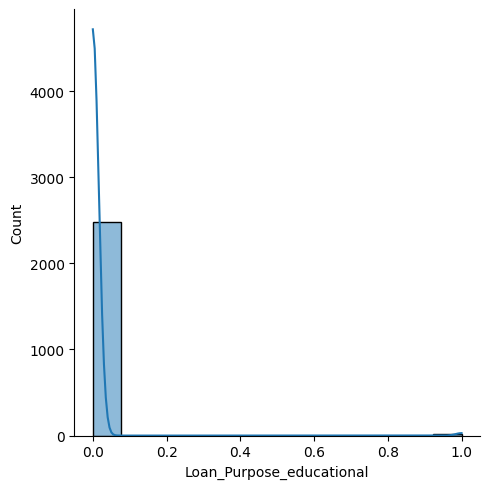

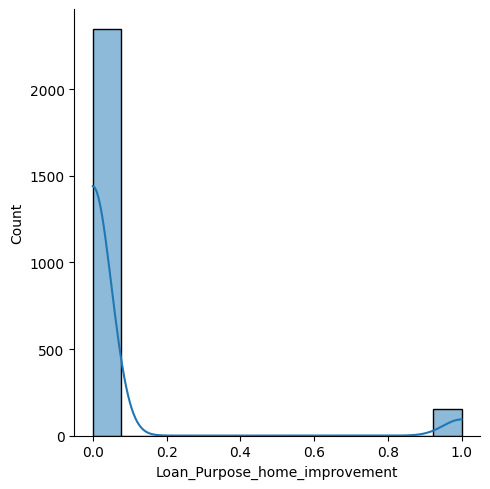

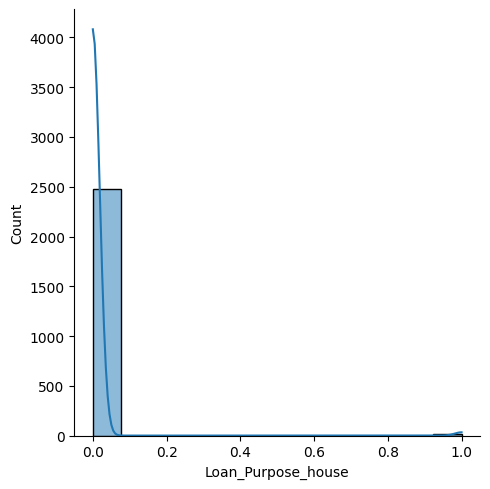

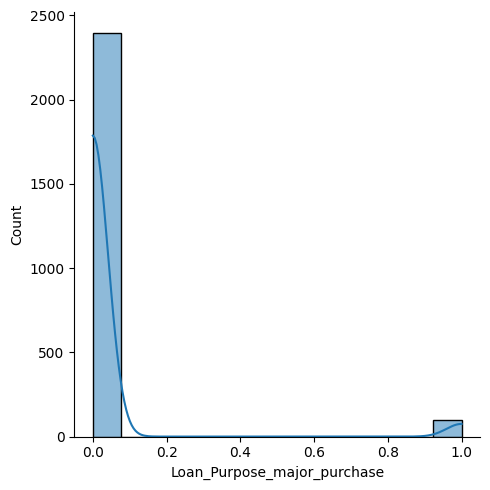

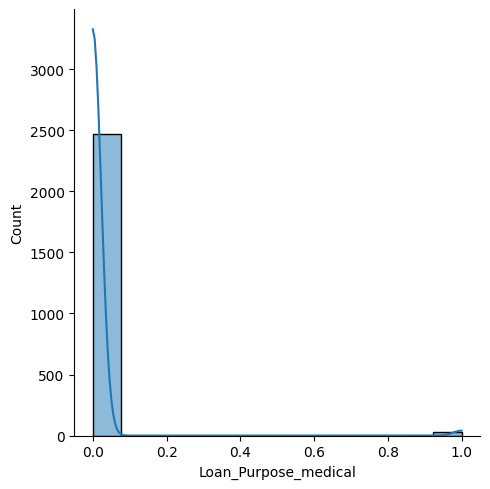

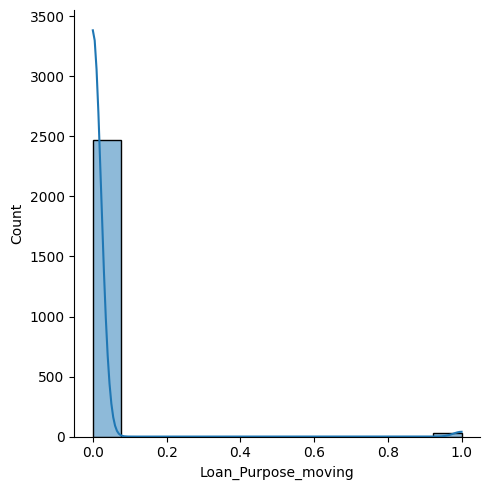

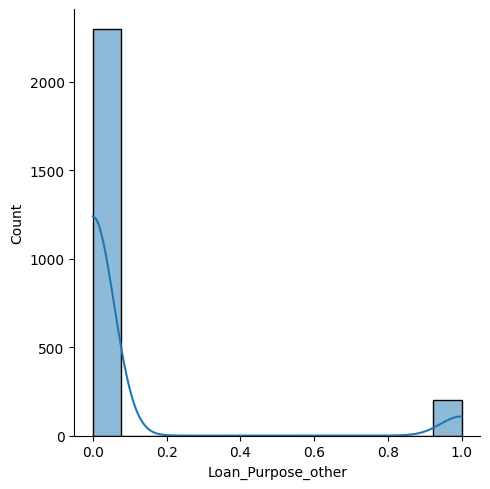

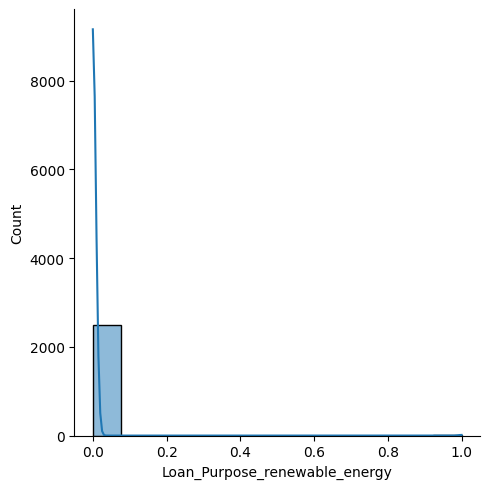

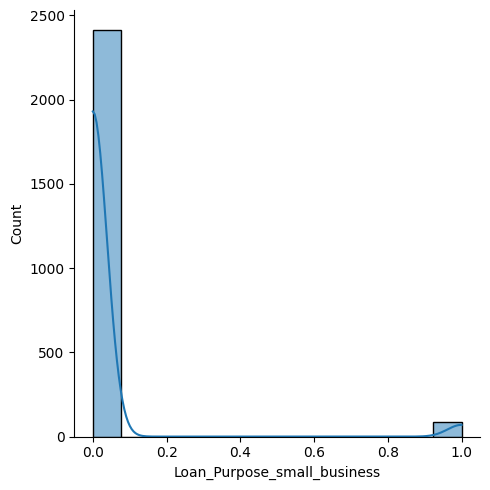

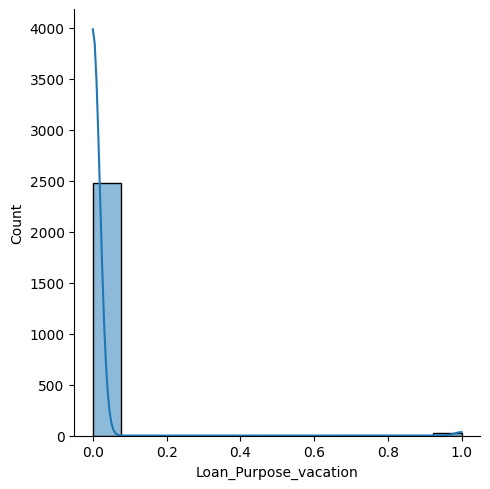

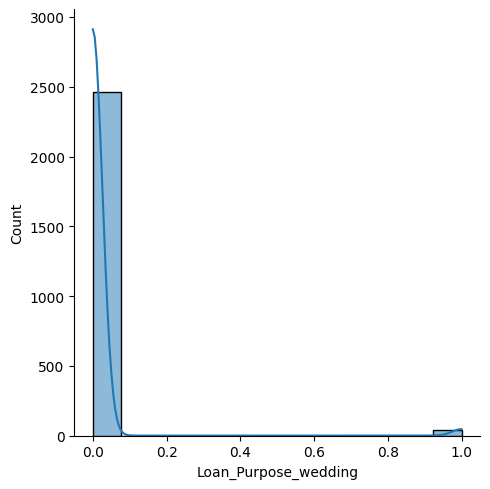

In [104]:
for col in merged_copy:
    sns.displot(merged_copy[col], kde = True)           #kde : kernel density estimation

#kde is actually an operator which provides a curve to the histograms and also defines the function of the curve

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Dell\AppData\Roaming\P

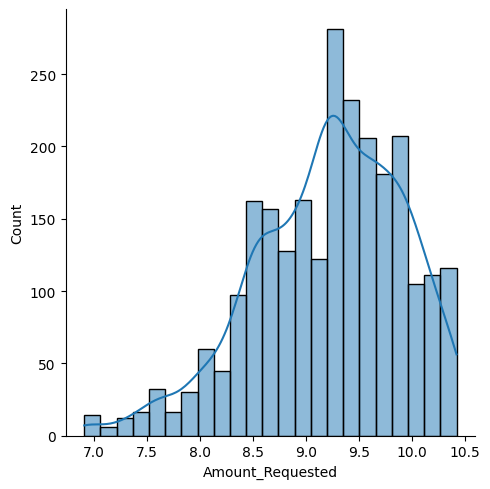

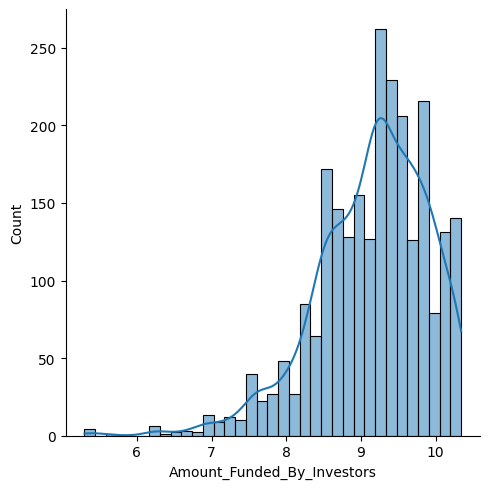

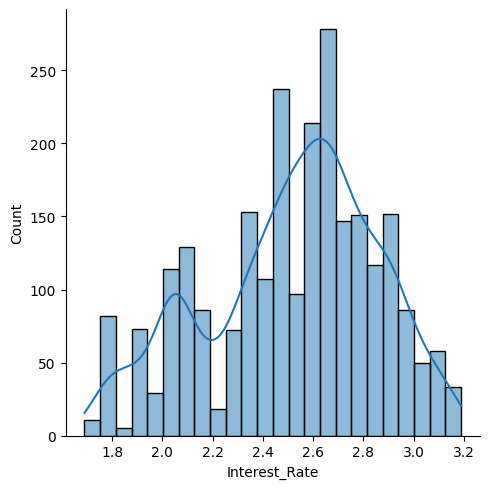

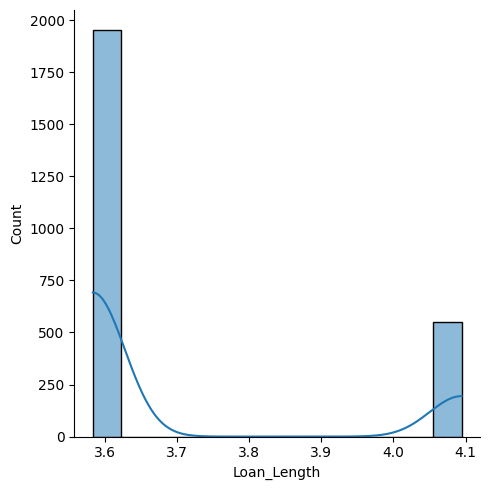

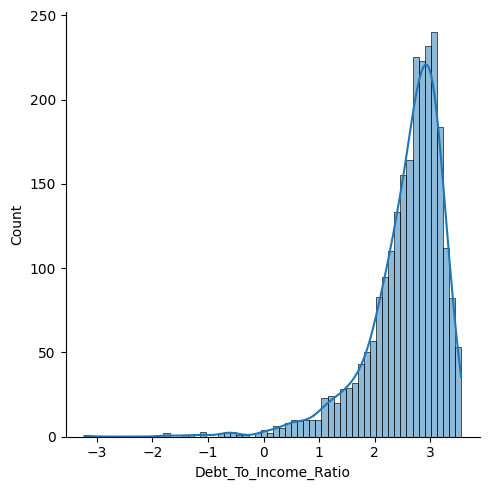

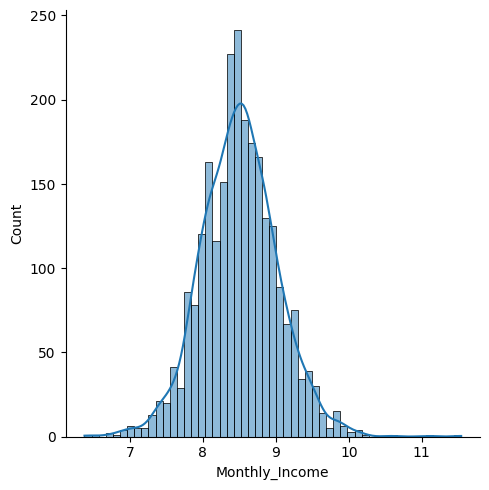

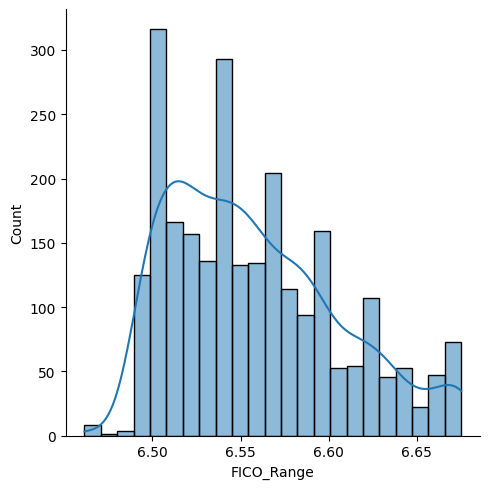

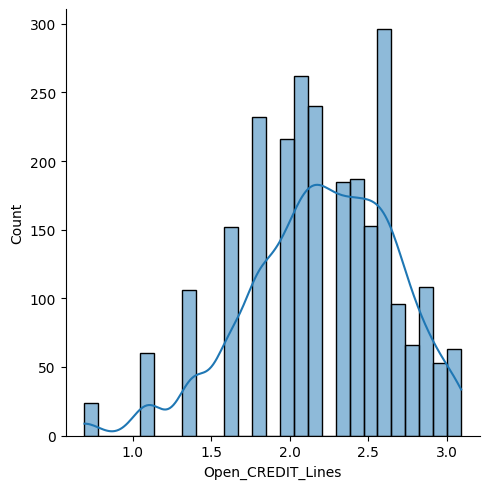

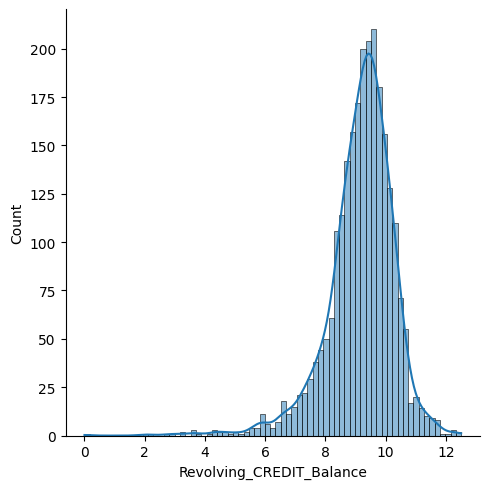

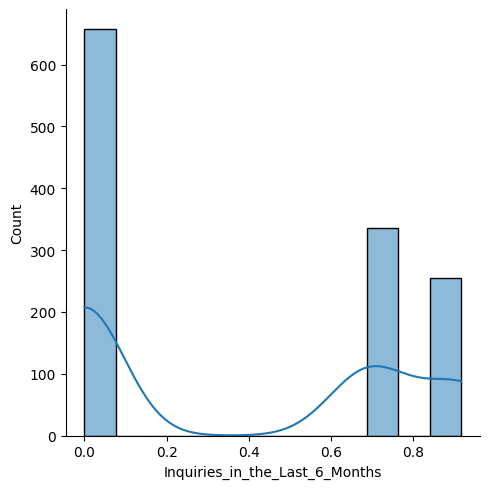

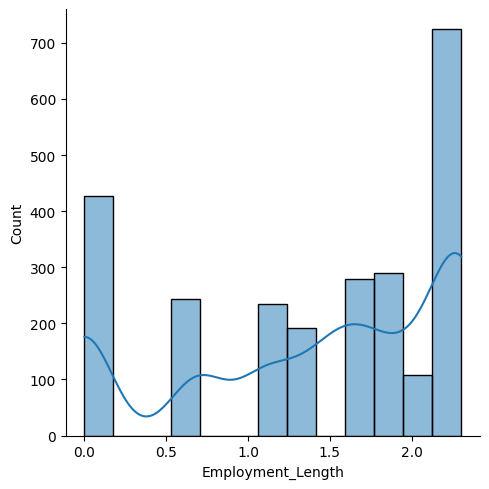

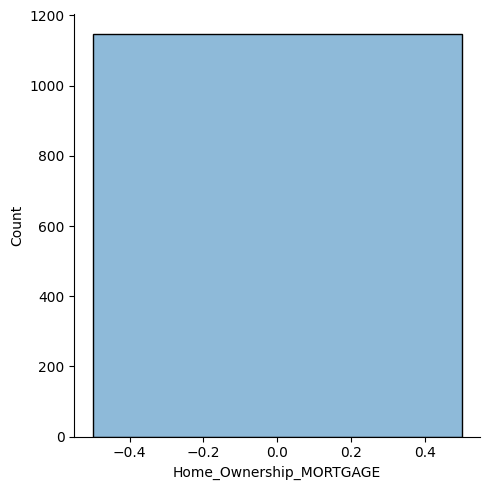

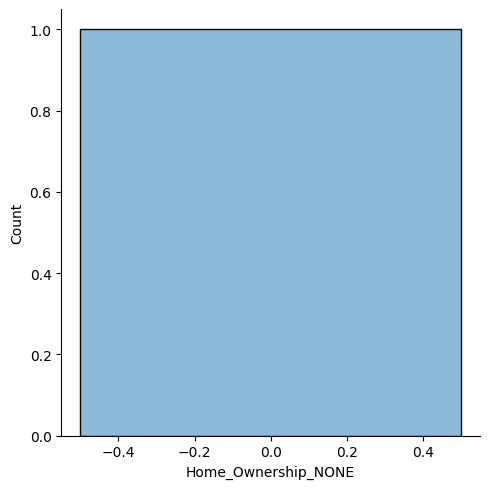

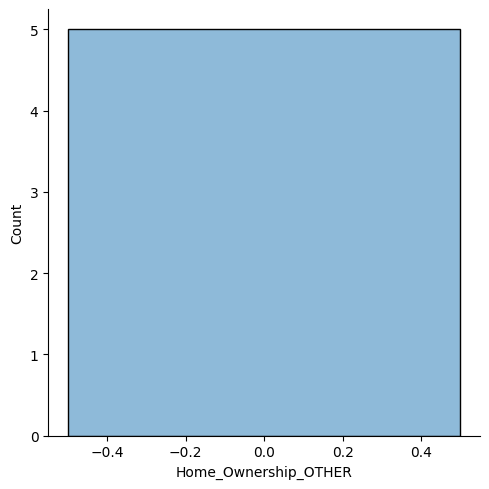

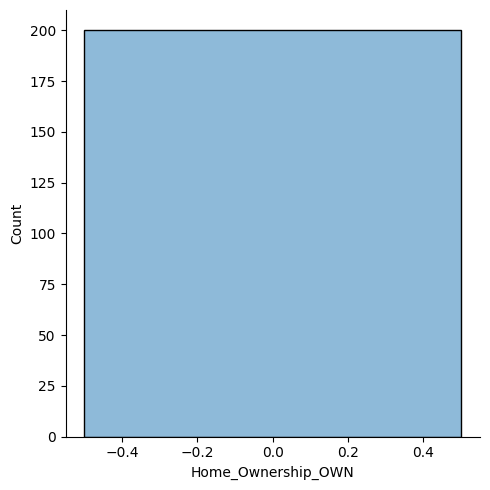

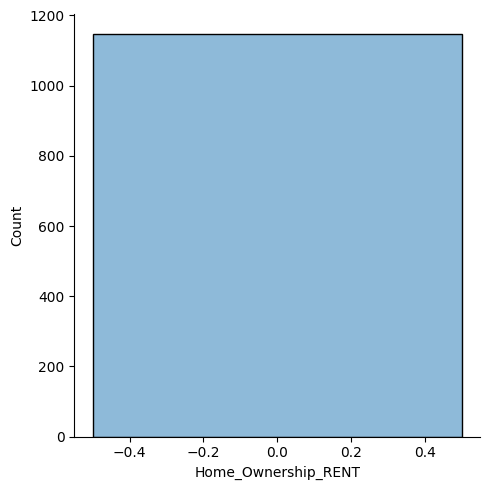

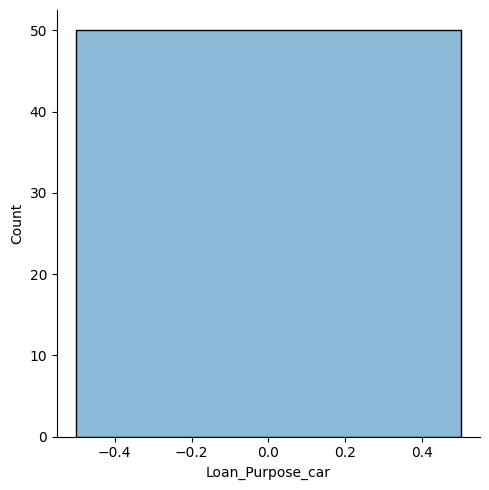

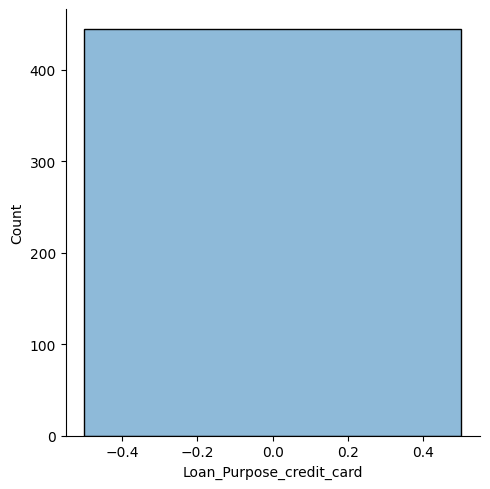

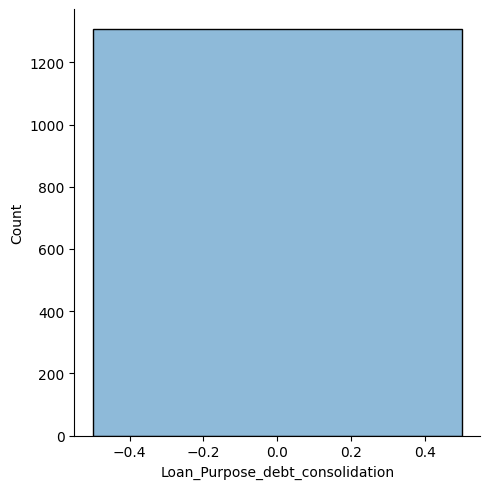

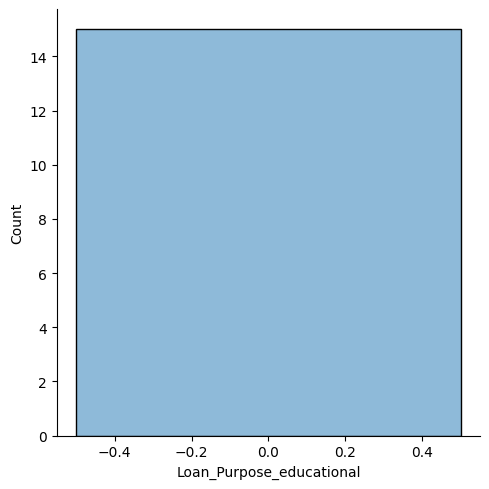

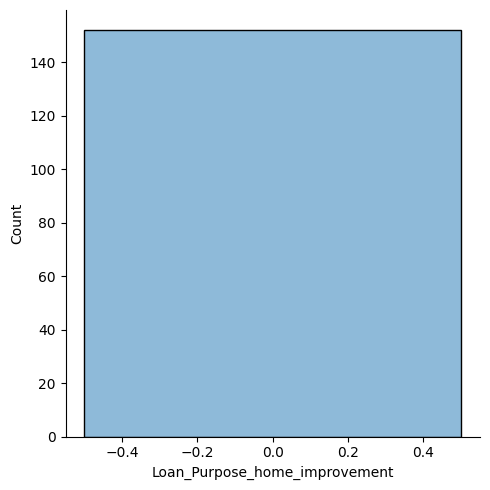

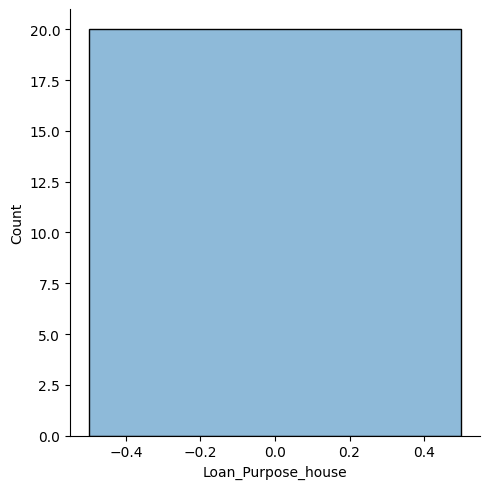

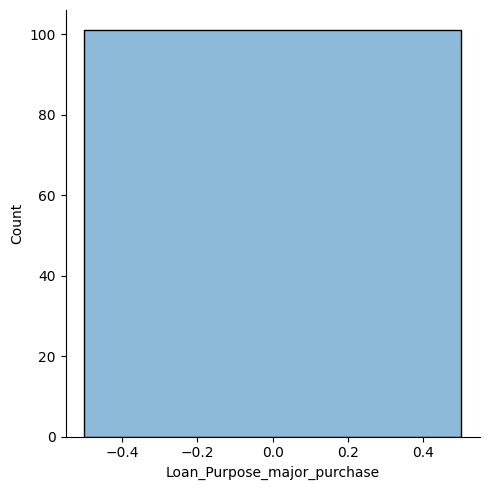

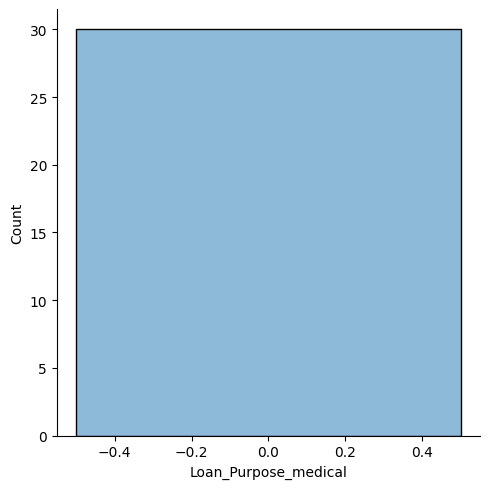

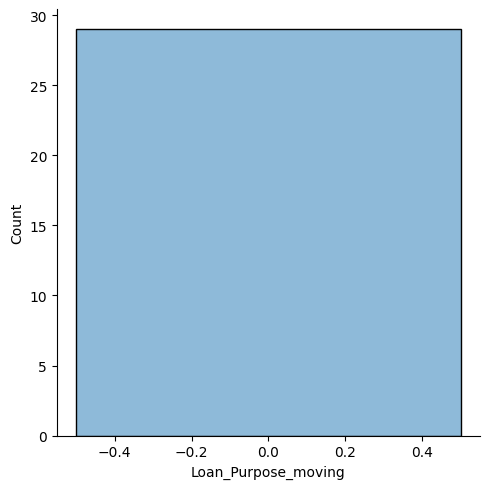

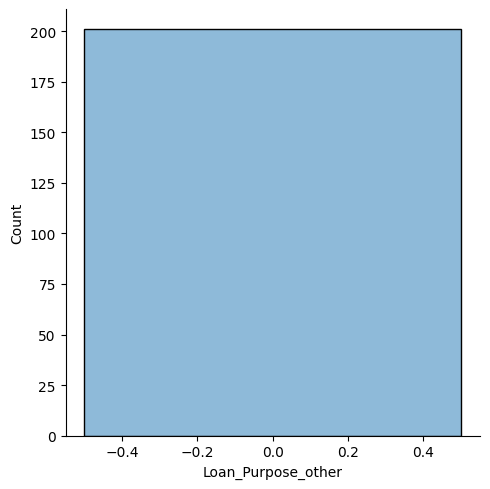

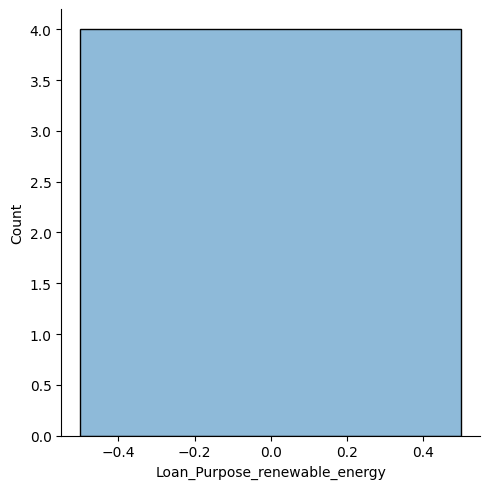

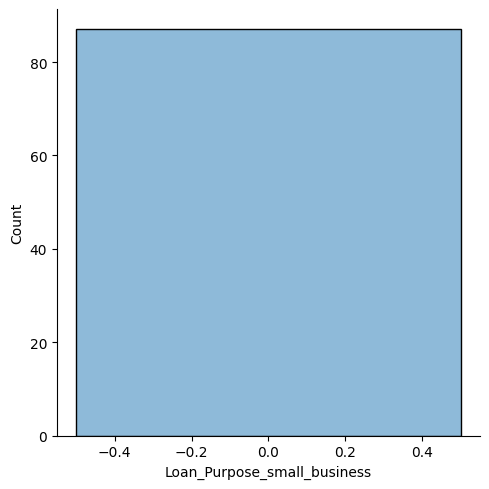

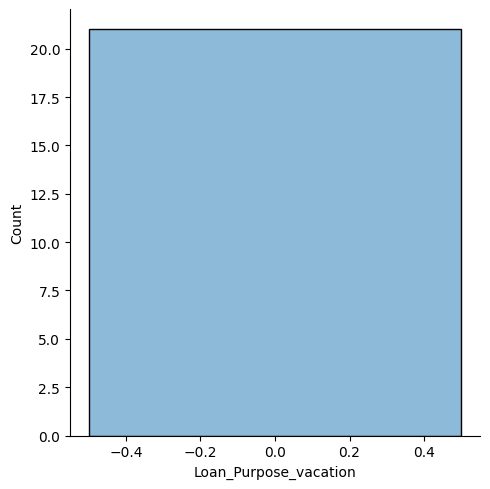

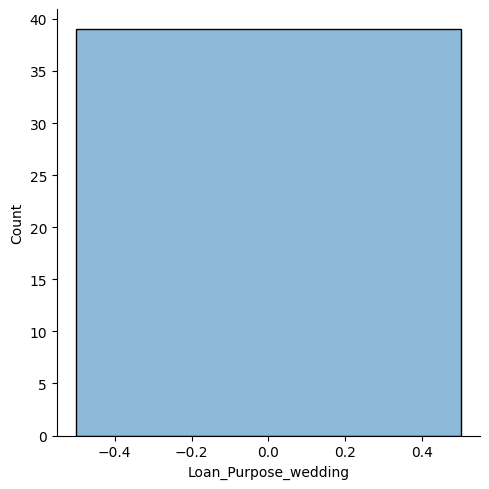

In [105]:
# displaying logarithmic graph of the column
for col in merged_copy.columns:
    sns.displot(np.log(merged_copy[col]),kde = True)

In [106]:
merged_copy['FICO_Range'].describe()             # don't apply log if a column has values < 1
                                                 # always check minimum-maximum using .describe() function

count    2499.000000
mean      705.655262
std        34.369002
min       640.000000
25%       680.000000
50%       700.000000
75%       725.000000
max       792.500000
Name: FICO_Range, dtype: float64

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


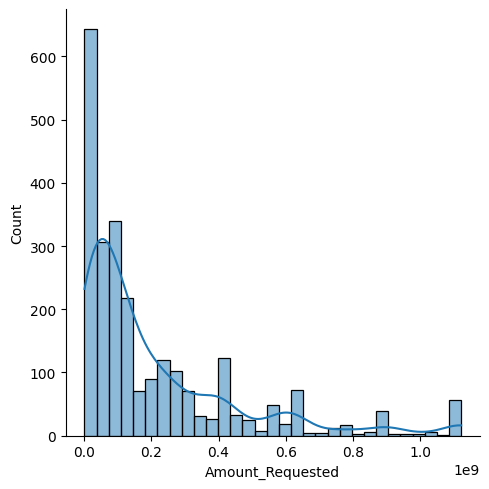

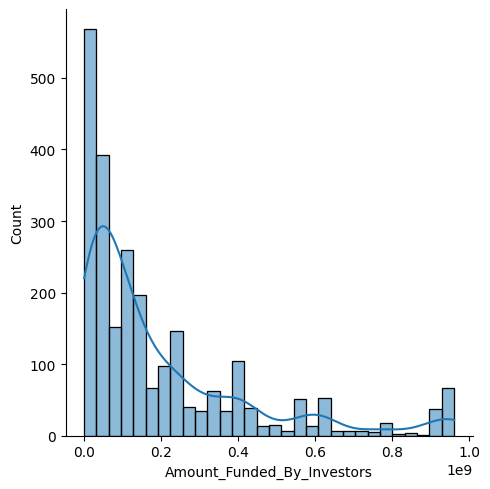

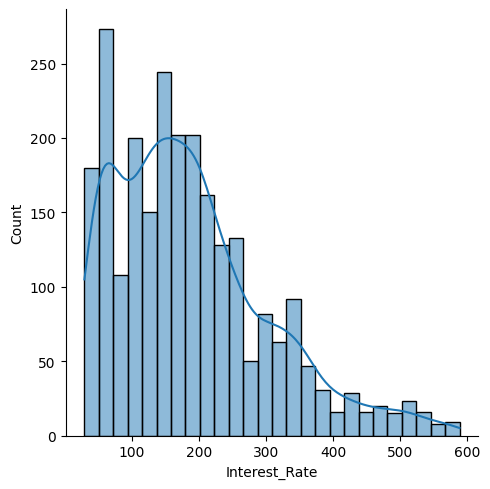

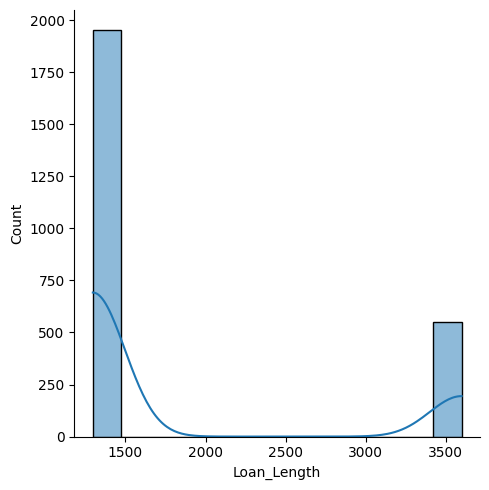

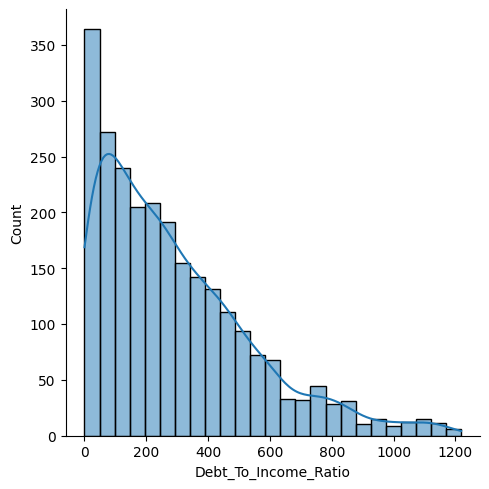

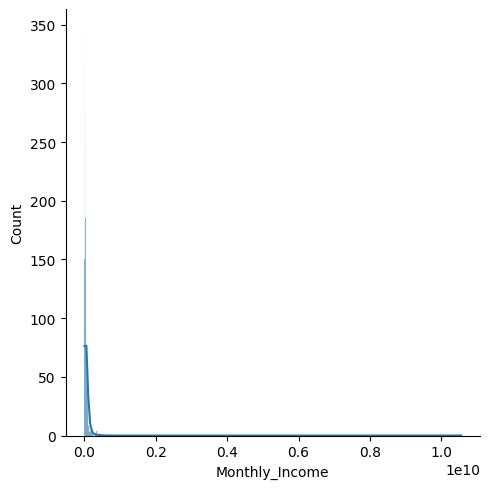

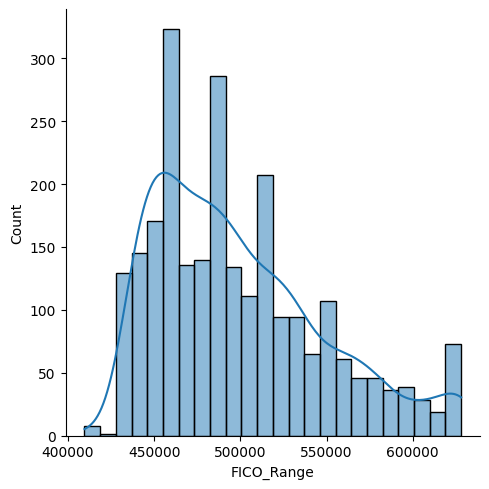

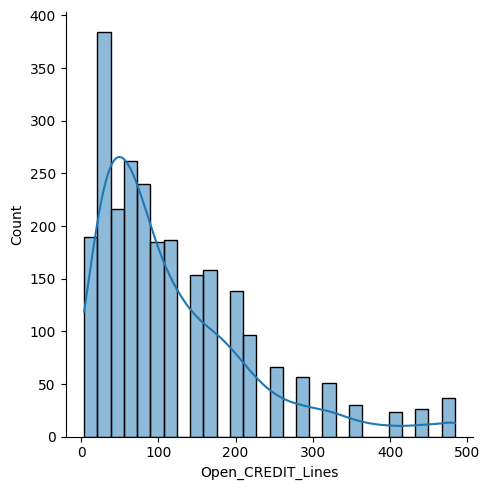

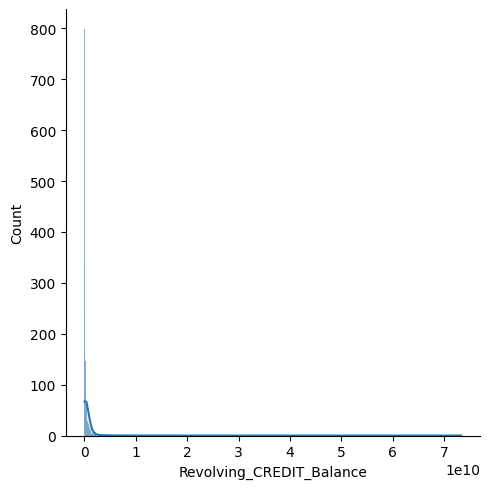

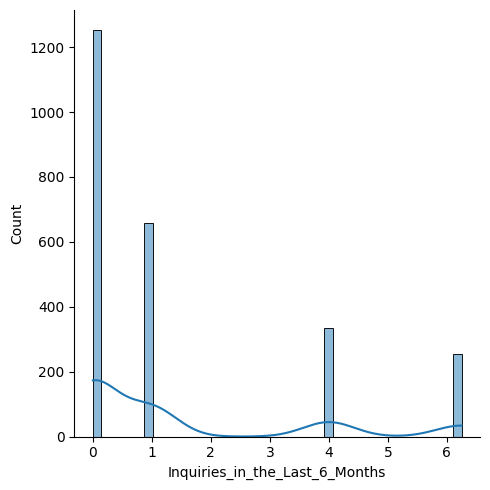

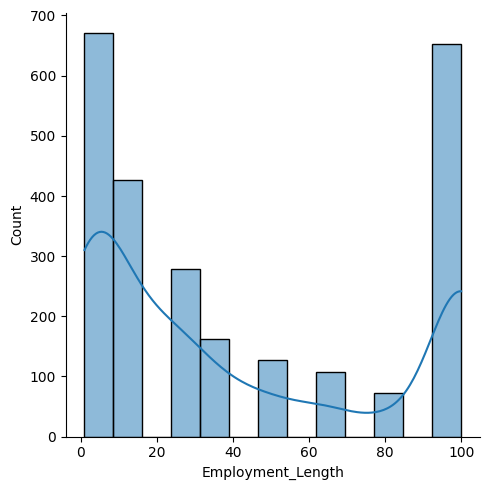

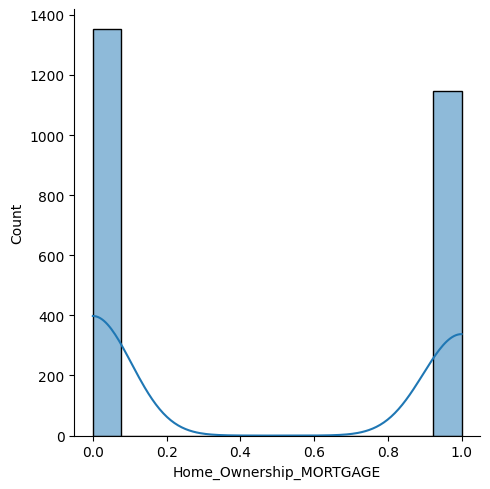

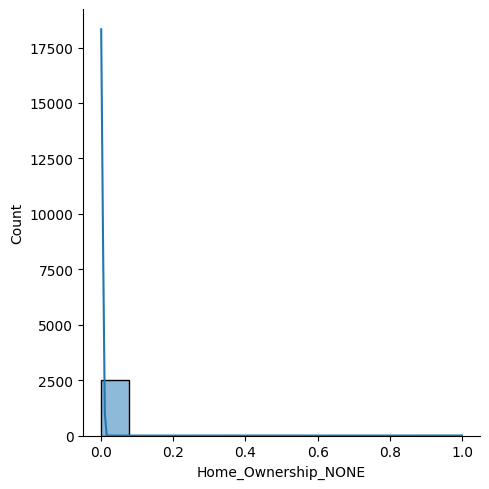

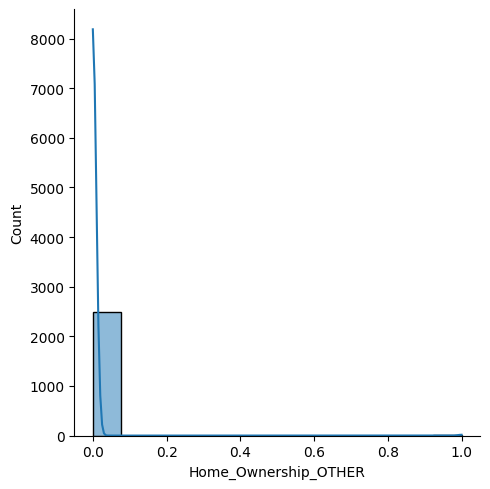

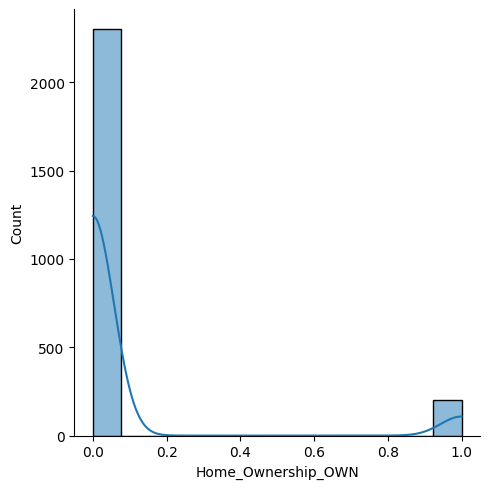

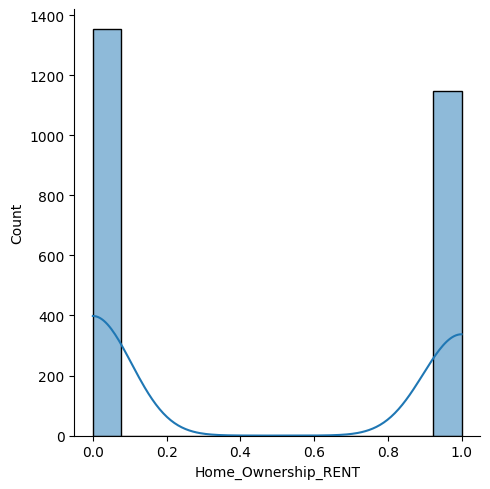

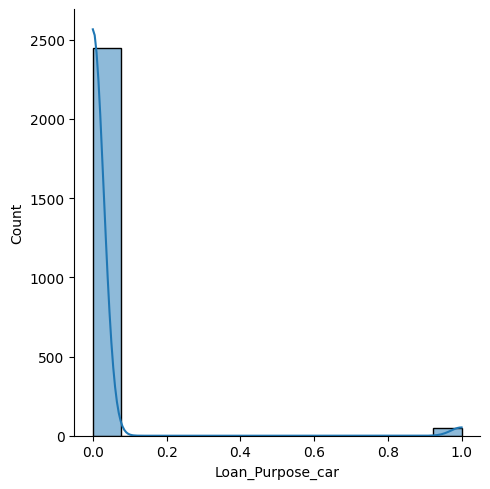

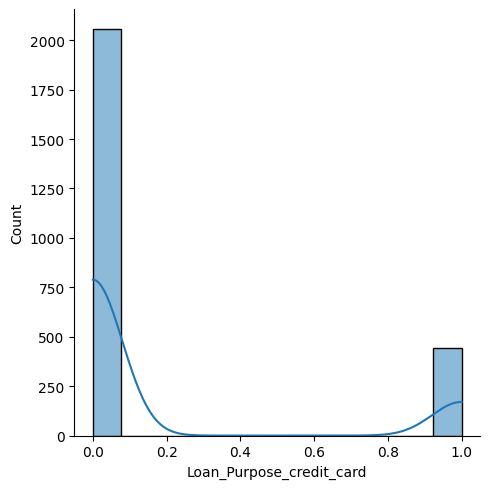

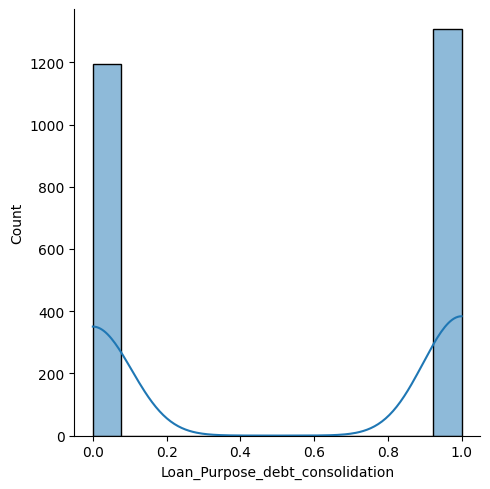

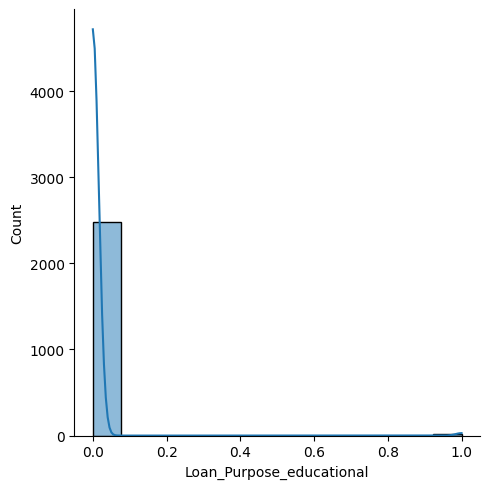

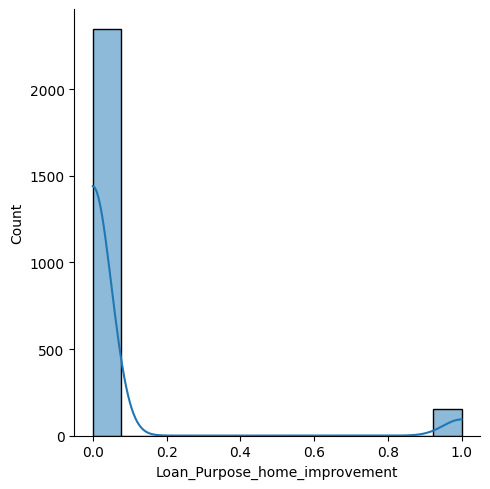

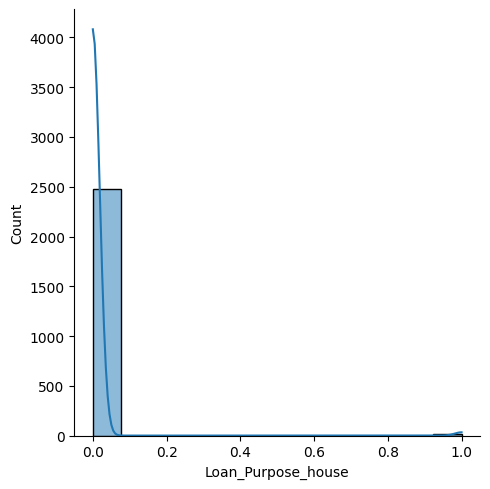

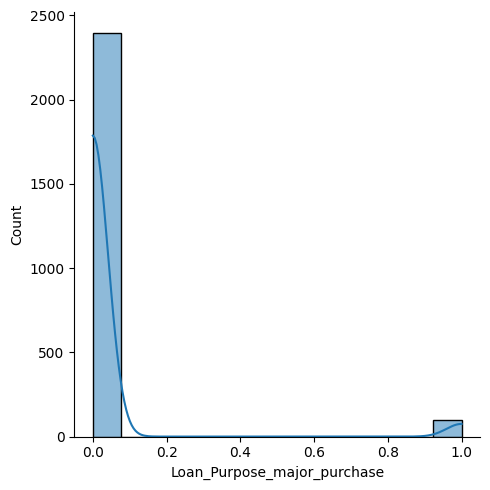

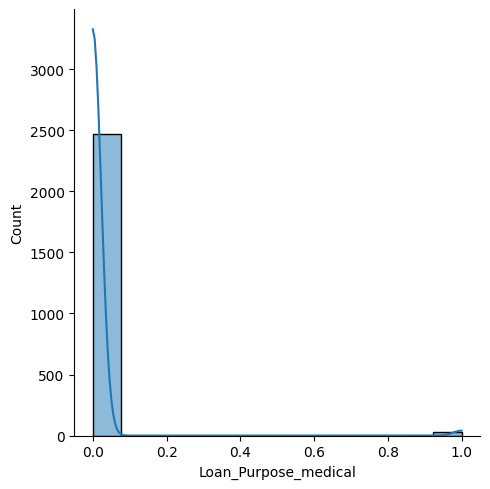

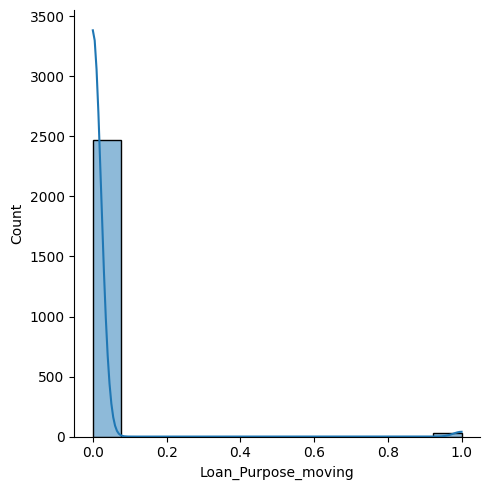

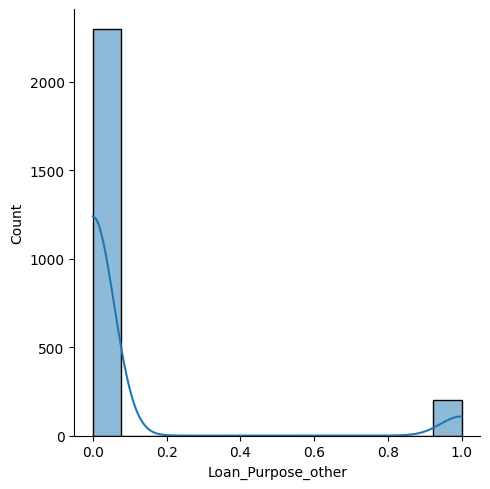

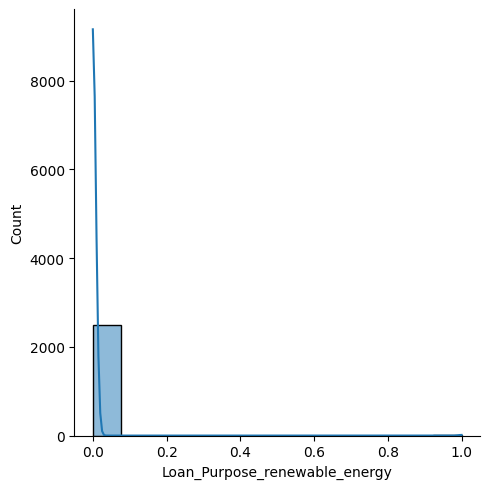

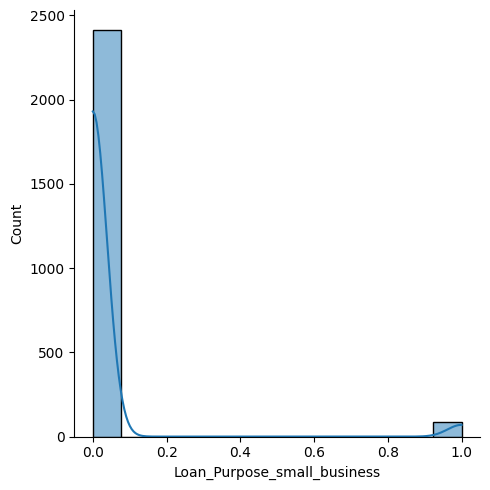

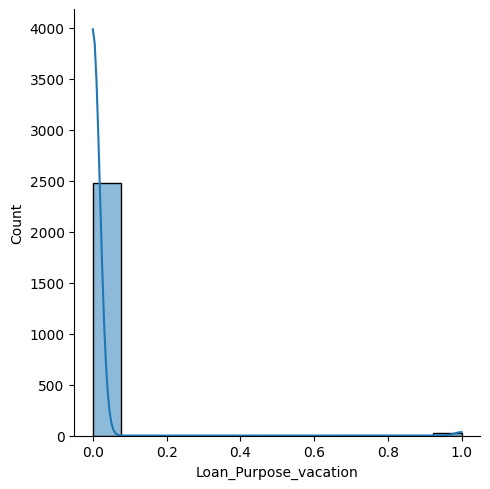

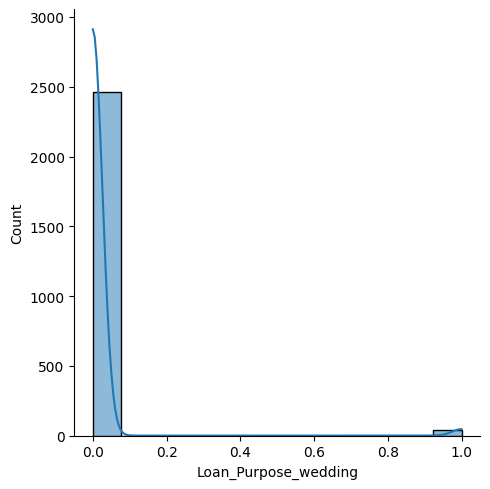

In [107]:
# displaying square graph of the column
for col in merged_copy.columns:
    sns.displot(np.square(merged_copy[col]),kde = True)

In [108]:
merged_copy1 = merged_copy.copy()

In [109]:
# Adding two columns by transforming them into normal distribution using log
merged_copy1['log_rate'] = np.log(merged_copy1['Interest_Rate'])
merged_copy1['log_ar'] = np.log(merged_copy1['Amount_Requested'])

In [110]:
merged_copy1.head(5)

,Amount_Requested,Amount_Funded_By_Investors,Interest_Rate,Loan_Length,Debt_To_Income_Ratio,Monthly_Income,FICO_Range,Open_CREDIT_Lines,Revolving_CREDIT_Balance,Inquiries_in_the_Last_6_Months,...,Loan_Purpose_major_purchase,Loan_Purpose_medical,Loan_Purpose_moving,Loan_Purpose_other,Loan_Purpose_renewable_energy,Loan_Purpose_small_business,Loan_Purpose_vacation,Loan_Purpose_wedding,log_rate,log_ar
0,20000.0,20000.0,8.90,36.0,14.90,6541.67,735.0,14.0,14272.0,2.0,...,0,0,0,0,0,0,0,0,2.186051,9.903488
1,19200.0,19200.0,12.12,36.0,28.36,4583.33,715.0,12.0,11140.0,1.0,...,0,0,0,0,0,0,0,0,2.494857,9.862666
2,33500.0,31000.0,21.98,60.0,23.81,11500.00,690.0,14.0,21977.0,1.0,...,0,0,0,0,0,0,0,0,3.090133,10.419301
3,10000.0,9975.0,9.99,36.0,14.30,3833.33,695.0,10.0,9346.0,0.0,...,0,0,0,0,0,0,0,0,2.301585,9.210340
4,12000.0,12000.0,11.71,36.0,18.78,3195.00,695.0,11.0,14469.0,0.0,...,0,0,0,0,0,0,0,0,2.460443,9.392662


In [111]:
merged_copy1 = merged_copy1.drop(columns = "Amount_Requested")                    # dropping Amount_Requested columns from the data

In [112]:
merged_copy1.head(5) 

,Amount_Funded_By_Investors,Interest_Rate,Loan_Length,Debt_To_Income_Ratio,Monthly_Income,FICO_Range,Open_CREDIT_Lines,Revolving_CREDIT_Balance,Inquiries_in_the_Last_6_Months,Employment_Length,...,Loan_Purpose_major_purchase,Loan_Purpose_medical,Loan_Purpose_moving,Loan_Purpose_other,Loan_Purpose_renewable_energy,Loan_Purpose_small_business,Loan_Purpose_vacation,Loan_Purpose_wedding,log_rate,log_ar
0,20000.0,8.90,36.0,14.90,6541.67,735.0,14.0,14272.0,2.0,1.0,...,0,0,0,0,0,0,0,0,2.186051,9.903488
1,19200.0,12.12,36.0,28.36,4583.33,715.0,12.0,11140.0,1.0,2.0,...,0,0,0,0,0,0,0,0,2.494857,9.862666
2,31000.0,21.98,60.0,23.81,11500.00,690.0,14.0,21977.0,1.0,2.0,...,0,0,0,0,0,0,0,0,3.090133,10.419301
3,9975.0,9.99,36.0,14.30,3833.33,695.0,10.0,9346.0,0.0,5.0,...,0,0,0,0,0,0,0,0,2.301585,9.210340
4,12000.0,11.71,36.0,18.78,3195.00,695.0,11.0,14469.0,0.0,9.0,...,0,0,0,0,0,0,0,0,2.460443,9.392662


### **Feature Engineering**

Feature Engineering:
Feature Selection/Feature Elimination

1. Elimination of Nominal Categorical variables
3. If cardinality (No. of Unique values) is 1. Eliminate it
4. Correlation technique (Mass variable Reduction, based on cut-off)
5. Colinearity : Relation (correlation) of any X variable with the Y variable.

Interview Question: The correlation of Amount of Rainfall and Production of Crop is 0.87, what is the significance of this ?


Ans. If one variable is increasing by one unit then other variable will increase by 0.87 respected to that.
Only Magnitude matters not signs in correlation

In [113]:
corr = merged_copy1.corrwith(merged_copy1['log_rate']).abs().sort_values(ascending = False)            # abs() to eliminate signs
corr

log_rate                           1.000000
Interest_Rate                      0.981617
FICO_Range                         0.746084
Loan_Length                        0.386505
Amount_Funded_By_Investors         0.304772
log_ar                             0.265184
Inquiries_in_the_Last_6_Months     0.196737
Debt_To_Income_Ratio               0.179015
Loan_Purpose_debt_consolidation    0.134933
Loan_Purpose_major_purchase        0.111816
Loan_Purpose_home_improvement      0.099785
Home_Ownership_RENT                0.086610
Home_Ownership_MORTGAGE            0.080279
Loan_Purpose_car                   0.071440
Open_CREDIT_Lines                  0.066097
Revolving_CREDIT_Balance           0.060728
Loan_Purpose_medical               0.045823
Loan_Purpose_educational           0.036408
Employment_Length                  0.035838
Home_Ownership_OTHER               0.032258
Loan_Purpose_renewable_energy      0.031320
Home_Ownership_NONE                0.030112
Loan_Purpose_wedding            

In [114]:
merged_copy1.corrwith(merged_copy1['log_rate']).abs().sort_values(ascending = False).mean()
# Finding Mean cutoff

np.float64(0.16440966528172418)

In [115]:
merged_copy1.corrwith(merged_copy1['log_rate']).abs().sort_values(ascending = False).median()
# Finding Median Cutoff

np.float64(0.060727537989746165)

In [116]:
# Taking cut-off : 0.05
v = corr[np.abs(corr)>0.05]
v

log_rate                           1.000000
Interest_Rate                      0.981617
FICO_Range                         0.746084
Loan_Length                        0.386505
Amount_Funded_By_Investors         0.304772
log_ar                             0.265184
Inquiries_in_the_Last_6_Months     0.196737
Debt_To_Income_Ratio               0.179015
Loan_Purpose_debt_consolidation    0.134933
Loan_Purpose_major_purchase        0.111816
Loan_Purpose_home_improvement      0.099785
Home_Ownership_RENT                0.086610
Home_Ownership_MORTGAGE            0.080279
Loan_Purpose_car                   0.071440
Open_CREDIT_Lines                  0.066097
Revolving_CREDIT_Balance           0.060728
dtype: float64

In [117]:
v = list(v.index)
new_data = merged_copy1[v]

In [118]:
new_data.head()
new_data.shape

(2499, 16)

### **Splitting the dataset into training and test data**


Training Data : 80%    

Test Data : 20%

In [119]:
# Scikitlearn : is a newer module for splitting in machine learning
# Stat's model : is the older module in ml

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
train, test = train_test_split(new_data, test_size = 0.2, random_state = 2)

In [122]:
# Checking the shape of train data
train.shape        

(1999, 16)

In [123]:
# Checking the shape of test data
test.shape

(500, 16)

### **Model Building : OLS Model**

Stats Model

In [124]:
train.columns

Index(['log_rate', 'Interest_Rate', 'FICO_Range', 'Loan_Length',
       'Amount_Funded_By_Investors', 'log_ar',
       'Inquiries_in_the_Last_6_Months', 'Debt_To_Income_Ratio',
       'Loan_Purpose_debt_consolidation', 'Loan_Purpose_major_purchase',
       'Loan_Purpose_home_improvement', 'Home_Ownership_RENT',
       'Home_Ownership_MORTGAGE', 'Loan_Purpose_car', 'Open_CREDIT_Lines',
       'Revolving_CREDIT_Balance'],
      dtype='object')

In [125]:
formula = 'log_rate~'+'+'.join(train.columns.difference(['log_rate','Interest_Rate','Loan_Purpose_major_purchase','Loan_Purpose_car','Home_Ownership_RENT','Loan_Purpose_debt_consolidation','Amount_Funded_By_Investors','Debt_To_Income_Ratio','Loan_Purpose_home_improvement','Revolving_CREDIT_Balance']))

In [126]:
import statsmodels.formula.api as smf

In [127]:
ols_model = smf.ols(formula,data = train).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rate   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     1123.
Date:                Tue, 15 Jul 2025   Prob (F-statistic):               0.00
Time:                        11:35:43   Log-Likelihood:                 791.92
No. Observations:                1999   AIC:                            -1570.
Df Residuals:                    1992   BIC:                            -1531.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [128]:
pred = pd.DataFrame(np.exp(ols_model.predict(train)))

In [129]:
pred['actual'] = train['Interest_Rate']

In [130]:
pred = pred.rename(columns = {0:"prediction"})

In [131]:
pred['absolute_percent_error'] = (np.abs(pred['actual'] - pred['prediction'])/pred['actual'])*100

In [132]:
MAPE = np.mean(pred['absolute_percent_error']).round(2)
MAPE

np.float64(12.29)